In [1]:
from explore_import import  *
import data_preprocess as dt
import ionbot_preprocess as io

from matplotlib.patches import Patch
from scipy.stats import chi2_contingency
from scipy.stats import wilcoxon
import itertools
import statsmodels.api as sm
from statsmodels.formula.api import ols
warnings.simplefilter(action='ignore', category=FutureWarning)

In [148]:
from scipy import stats

In [2]:
root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
# where to get pickles
results_dir = f"{root}/oui-discovery-vv-data/pickles"
PIPELINE_CL = 'ionbot_closed' ; PIPELINE_CL_LW = PIPELINE_CL.lower()
PIPELINE_N_NAME = 'ionbot' ; PIPELINE_N_MODE = 'open' ; PIPELINE_N = f'{PIPELINE_N_NAME}_{PIPELINE_N_MODE}'; PIPELINE_N_LW = PIPELINE_N.lower()
COMPARE = f'{PIPELINE_CL_LW}_{PIPELINE_N_LW}'
# save plots
plot_dir = f'{root}/oui-discovery-vv-plot/{COMPARE}'

In [3]:
project_palette={"canon":"orangered","trembl":"yellowgreen","openprot":"cornflowerblue"}
proteins_palette={"Canonical":"orangered","Non-canonical":"cornflowerblue","Reference isoforms":"yellowgreen","Novel isoforms":"gold"}
project_palette2={"canon":"orangered","trembl":"yellowgreen","openprot":"cornflowerblue",
                "Canon_unique":"salmon", "NonCanon_unique":"skyblue", "Shared":"darkkhaki",
                "Canon":"firebrick","Noncanon":"steelblue",f"{PIPELINE_CL}_canon":"lightcoral",f"{PIPELINE_CL}_trembl":"greenyellow",f"{PIPELINE_CL}_openprot":"paleturquoise",
                  "ionbot_canon":"orangered","ionbot_trembl":"yellowgreen","ionbot_openprot":"cornflowerblue",
                 f"{PIPELINE_CL}_canon_unique":"chocolate",
                  f"{PIPELINE_CL}_canon_unique_shared_in_class":"saddlebrown",
                  f"{PIPELINE_CL}_noncanon_unique":"plum",
                  f"{PIPELINE_CL}_noncanon_unique_shared_in_class":"orchid",
                  f"{PIPELINE_CL}_shared":"tan",
                  "ionbot_canon_unique":"salmon",
                  "ionbot_canon_unique_shared_in_class":"rosybrown",
                  "ionbot_noncanon_unique":"skyblue",
                  "ionbot_noncanon_unique_shared_in_class":"mediumturquoise",
                  "ionbot_shared":"darkkhaki",
                 "ionbot_canon_unique_OnlyMod":"firebrick",
                 "ionbot_canon_unique_OnlyUnmod":"indianred",
                 "ionbot_canon_unique_Both":"lightcoral",
                 "ionbot_noncanon_unique_OnlyMod":"royalblue",
                 "ionbot_noncanon_unique_OnlyUnmod":"dodgerblue",
                 "ionbot_noncanon_unique_Both":"lightblue",
                 "ionbot_shared_OnlyMod":"olivedrab",
                 "ionbot_shared_OnlyUnmod":"olive",
                 "ionbot_shared_Both":"darkseagreen",}

In [4]:
peptide_class_order = ["Canon_unique","Shared","NonCanon_unique"]
peptide_classes={"NonCanon_unique":["unique_to_Noncanon",'shared_in_Noncanon'],
                "Canon_unique":["unique_to_Canon",'shared_in_Canon'],
                "Shared":['shared_btw_can_noncan']}
peptide_subclasses = {subcl:pepcl for pepcl, pepsubcl in peptide_classes.items() for subcl in pepsubcl}

In [5]:
dataset_palette={'PXD002057':"lightgrey" ,'PXD005833': 'darkgrey', 'PXD014258': 'dimgrey'}

In [6]:
database_map = {'canon':'Swiss-Prot','trembl':'TrEMBL','openprot':'OpenProt'}
database_order = ["canon","trembl","openprot"]
database_title_order = ["Swiss-Prot","TrEMBL","OpenProt"]

In [7]:
# significance helper
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

### ID rate by database search

/tmp/ipykernel_72322/2805326940.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  l = ax.legend().get_frame()


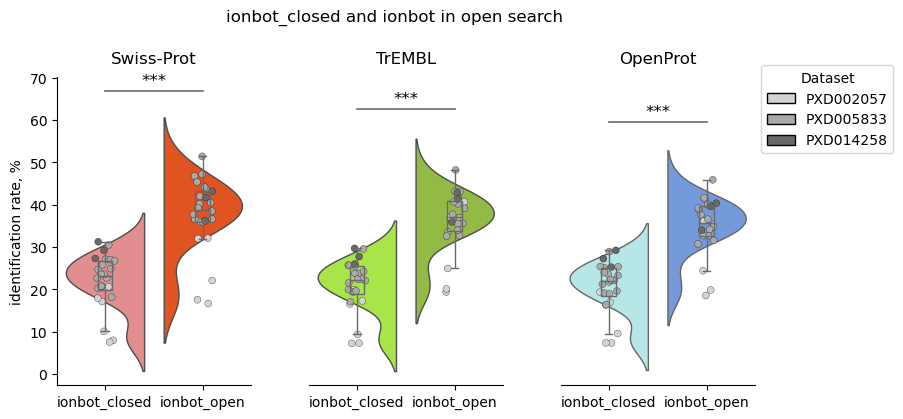

In [8]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_idrate_datasets_df.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_idrate_datasets_df.pkl")
# concat
data = pd.concat([data_cl, data_n])
# correct dataset
data['dataset'] = data['dataset'].str.replace('.v0.11.4','')
# percent
data['value'] *= 100
# plot
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=True)
fig.suptitle(f"{PIPELINE_CL} and {PIPELINE_N_NAME} in {PIPELINE_N_MODE} search", y=1.05)

for i, database in enumerate(database_order):
    subset = data[data['database'] == database]

    # violin
    sns.violinplot(data=subset, 
                   x='pipeline', y='value', 
                   split=True, hue='pipeline', ax=axes[i],
                   inner=None, dodge=False,
                   palette={PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{database}"], 
                            PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{database}"]},
                   linewidth=1)

    # scatter overlay
    for dataset in dataset_palette.keys():
        sns.stripplot(x="pipeline", y="value", hue="dataset",
                      data=subset[subset.dataset == dataset], 
                      jitter=True, ax=axes[i],
                      palette=dataset_palette, edgecolor="black", linewidth=0.2,
                      legend=False, zorder=10)

    # box overlay
    sns.boxplot(data=subset,
                x='pipeline', y='value',
                width=0.15, dodge=False,
                boxprops={"facecolor": "none", "edgecolor": "dimgrey", "linewidth": 1},
                whiskerprops={"color": "dimgrey", "linewidth": 1},
                capprops={"color": "dimgrey", "linewidth": 1},
                medianprops={"color": "dimgrey", "linewidth": 1},
                showfliers=False, ax=axes[i], zorder=50)

    # --- Wilcoxon test between pipelines ---
    vals_cl = subset[subset['pipeline'] == PIPELINE_CL]['value']
    vals_n = subset[subset['pipeline'] == PIPELINE_N]['value']

    # Only test if both groups have paired samples and >0 values
    try:
        if len(vals_cl) == len(vals_n) and len(vals_cl) > 0:
            stat, p = wilcoxon(vals_cl, vals_n)
            stars = significance_stars(p)

            # Add annotation
            y_max = max(subset['value']) * 1.3
            axes[i].plot([0, 1], [y_max, y_max], color='dimgray', lw=1.2)
            axes[i].text(0.5, y_max * 1.01, stars, ha='center', va='bottom', fontsize=12)
    except ValueError:
        # Skip if not paired
        pass

    axes[i].set_title(database_map[database], pad=10)

# aesthetics
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('') 
    ax.set_xlabel('')
    ax.tick_params(left=False) 
    l = ax.legend().get_frame()
    l.set_edgecolor("white")

# Keep only y-axis on first plot
axes[0].spines['left'].set_visible(True)
axes[0].set_ylabel("identification rate, %") 
axes[0].tick_params(left=True)

# dataset legend
legend_handles = [Patch(facecolor=color, edgecolor='black', label=dataset)
                  for dataset, color in dataset_palette.items()]
fig.legend(handles=legend_handles, title="Dataset", loc='center left', bbox_to_anchor=(0.9, 0.8), frameon=True)

fig.subplots_adjust(wspace=.3)

plt.savefig(f"{plot_dir}/idrate_by_db.svg", format='svg', bbox_inches = 'tight')

### ID rate by peptide class

#### all

In [9]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_PEPCL_idrate_datasets_df.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_PEPCL_idrate_datasets_df.pkl")
# concat
data = pd.concat([data_cl, data_n])
# correct dataset
data['dataset'] = data['dataset'].str.replace('.v0.11.4','')
# percent
data['value'] *= 100
#remove decoy
data = data[data['peptide_class']!='decoy']
# map subclass by class
data['peptide_class'] = data['peptide_class'].map(peptide_subclasses)
# sum entries of same class per sample and pipeline
data = data.groupby(['pipeline', 'dataset', 'sample', 'peptide_class']).apply(lambda x: x['value'].sum()).to_frame().reset_index().rename(columns={0:'value'})

/tmp/ipykernel_72322/1335359121.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  l=ax.legend().get_frame()


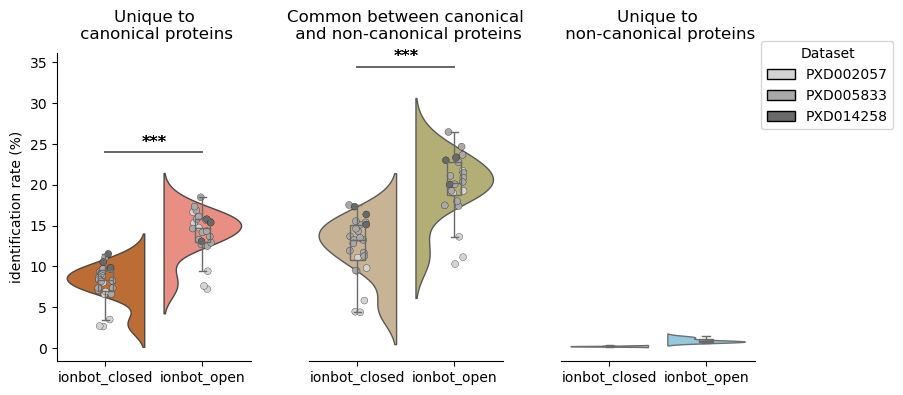

In [10]:
#plot
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=True)
#Left plot
for i,peptide_class in enumerate(peptide_class_order):
    attribute= "canon_unique" if peptide_class=="Canon_unique" else "noncanon_unique" if peptide_class=="NonCanon_unique" else "shared"
    subset = data[data['peptide_class'] == peptide_class]
    v=sns.violinplot(data=subset, 
                   x='pipeline', y='value', 
                   split=True, hue='pipeline', ax=axes[i],
                   inner=None,dodge=False,
                   palette={PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{attribute}"], PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{attribute}"]},
                   linewidth=1,
                  )
    if peptide_class!="NonCanon_unique":
        for dataset in dataset_palette.keys():
            sns.stripplot(x="pipeline", y="value", hue="dataset", data=subset[(subset.dataset==dataset)], jitter=True, ax=axes[i],
                     palette=dataset_palette,edgecolor="black", linewidth=0.2 ,legend=False, zorder=10)
            # --- Wilcoxon test between pipelines ---
            vals_cl = subset[subset['pipeline'] == PIPELINE_CL]['value']
            vals_n = subset[subset['pipeline'] == PIPELINE_N]['value']
        
            # Only test if both groups have paired samples and >0 values
            try:
                if len(vals_cl) == len(vals_n) and len(vals_cl) > 0:
                    stat, p = wilcoxon(vals_cl, vals_n)
                    stars = significance_stars(p)
        
                    # Add annotation
                    y_max = max(subset['value']) * 1.3
                    axes[i].plot([0, 1], [y_max, y_max], color='dimgray', lw=1.2)
                    axes[i].text(0.5, y_max * 1.01, stars, ha='center', va='bottom', fontsize=12)
            except ValueError:
                # Skip if not paired
                pass
        
    sns.boxplot(data=subset,
                x='pipeline', y='value', 
                width=0.15,  # Keeps boxplot thin
                dodge=False,
                boxprops={"facecolor": "none", "edgecolor": "dimgrey", "linewidth": 1},  # Thinner box edges
                whiskerprops={"color": "dimgrey", "linewidth": 1},  # Thinner whiskers
                capprops={"color": "dimgrey", "linewidth": 1},  # Thinner caps
                medianprops={"color": "dimgrey", "linewidth": 1},  # Thinner dashed median line
                showfliers=False,  # Hide outliers
                ax=axes[i],
                zorder=50
    )

    attribute_txt= "Unique to\n canonical proteins" if peptide_class=="Canon_unique" else "Unique to\n non-canonical proteins" if peptide_class=="NonCanon_unique" else "Common between canonical\n and non-canonical proteins"
    axes[i].set_title(attribute_txt,pad=10)

#Customize
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('') 
    ax.set_xlabel('')
    ax.tick_params(left=False) 
    l=ax.legend().get_frame()
    l.set_edgecolor("white")

#Keep only the y-axis on the first plot
axes[0].spines['left'].set_visible(True)
axes[0].set_ylabel("identification rate (%)") 
axes[0].tick_params(left=True)

legend_handles = [Patch(facecolor=color, edgecolor='black', label=dataset)
                  for dataset, color in dataset_palette.items()]
fig.legend(handles=legend_handles, title="Dataset", loc='center left', bbox_to_anchor=(0.9, 0.8), frameon=True)

fig.subplots_adjust(wspace=.3)
#plt.tight_layout()

plt.savefig(f"{plot_dir}/idrate_by_pepcl.svg", format='svg', bbox_inches = 'tight')

#### Non-canonical

/tmp/ipykernel_72322/377172515.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  l=axes.legend().get_frame()


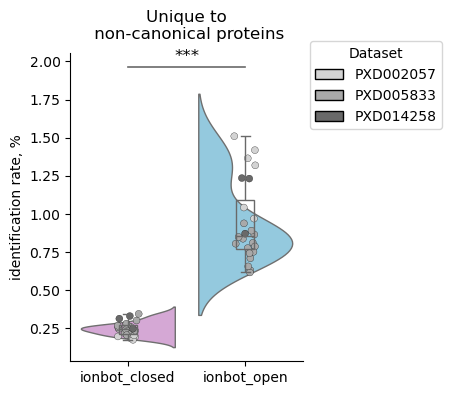

In [11]:
peptide_class_plot = 'NonCanon_unique'
data_plot= data[data['peptide_class'] == peptide_class_plot]

#plot
fig, axes = plt.subplots(1, 1, figsize=(3, 4), sharey=True)
#Left plot
for i,peptide_class in enumerate([peptide_class_plot]):
    attribute= "canon_unique" if peptide_class=="Canon_unique" else "noncanon_unique" if peptide_class=="NonCanon_unique" else "shared"
    subset = data_plot[data_plot['peptide_class'] == peptide_class]
    v=sns.violinplot(data=subset, 
                   x='pipeline', y='value', 
                   split=True, hue='pipeline', ax=axes,
                   inner=None,dodge=False,
                   palette={PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{attribute}"], PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{attribute}"]},
                   linewidth=1,
                  )
    for dataset in dataset_palette.keys():
        sns.stripplot(x="pipeline", y="value", hue="dataset", data=subset[(subset.dataset==dataset)], jitter=True, ax=axes,
                 palette=dataset_palette,edgecolor="black", linewidth=0.2 ,legend=False, zorder=10)
        
    sns.boxplot(data=data_plot[data_plot['peptide_class'] == peptide_class],
                x='pipeline', y='value', 
                width=0.15,  # Keeps boxplot thin
                dodge=False,
                boxprops={"facecolor": "none", "edgecolor": "dimgrey", "linewidth": 1},  # Thinner box edges
                whiskerprops={"color": "dimgrey", "linewidth": 1},  # Thinner whiskers
                capprops={"color": "dimgrey", "linewidth": 1},  # Thinner caps
                medianprops={"color": "dimgrey", "linewidth": 1},  # Thinner dashed median line
                showfliers=False,  # Hide outliers
                ax=axes,
                zorder=50
    )

    attribute_txt= "Unique to\n canonical proteins" if peptide_class=="Canon_unique" else "Unique to\n non-canonical proteins" if peptide_class=="NonCanon_unique" else "Common between canonical\n and non-canonical proteins"
    axes.set_title(attribute_txt, pad = 10)
    # --- Wilcoxon test between pipelines ---
    vals_cl = subset[subset['pipeline'] == PIPELINE_CL]['value']
    vals_n = subset[subset['pipeline'] == PIPELINE_N]['value']

    # Only test if both groups have paired samples and >0 values
    try:
        if len(vals_cl) == len(vals_n) and len(vals_cl) > 0:
            stat, p = wilcoxon(vals_cl, vals_n)
            stars = significance_stars(p)

            # Add annotation
            y_max = max(subset['value']) * 1.3
            axes.plot([0, 1], [y_max, y_max], color='dimgray', lw=1.2)
            axes.text(0.5, y_max * 1.01, stars, ha='center', va='bottom', fontsize=12)
    except ValueError:
        # Skip if not paired
        pass
#Customize
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False) 
axes.set_ylabel('') 
axes.set_xlabel('')
axes.tick_params(left=False) 
l=axes.legend().get_frame()
l.set_edgecolor("white")

#Keep only the y-axis on the first plot
axes.set_ylabel("identification rate, %") 
axes.tick_params(left=True)

legend_handles = [Patch(facecolor=color, edgecolor='black', label=dataset)
                  for dataset, color in dataset_palette.items()]
fig.legend(handles=legend_handles, title="Dataset", loc='center left', bbox_to_anchor=(0.9, 0.8), frameon=True)

fig.subplots_adjust(wspace=.3)
#plt.tight_layout()

plt.savefig(f"{plot_dir}/idrate_by_pepcl_noncanon.svg", format='svg', bbox_inches = 'tight')

### Peptide reproducability by datasets

In [12]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_peptides_across_samples_PEP_df.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_peptides_across_samples_PEP_df.pkl")
# concat
data = pd.concat([data_cl, data_n])
# correct dataset
data['dataset'] = data['dataset'].str.replace('.v0.11.4','')
#remove decoy
data = data[data['peptide_class']!='decoy']
# map subclass by class
data['peptide_class'] = data['peptide_class'].map(peptide_subclasses)
# sum entries of same class per sample and pipeline
data = data.groupby(['pipeline', 'dataset', 'peptide_class','n_samp']).apply(lambda x: x['value'].sum()).to_frame().reset_index().rename(columns={0:'value'})
# percent
data['percent'] = (
    data.groupby(['pipeline', 'dataset',  'peptide_class'])['value']
    .transform(lambda x: 100 * x / x.sum())
)

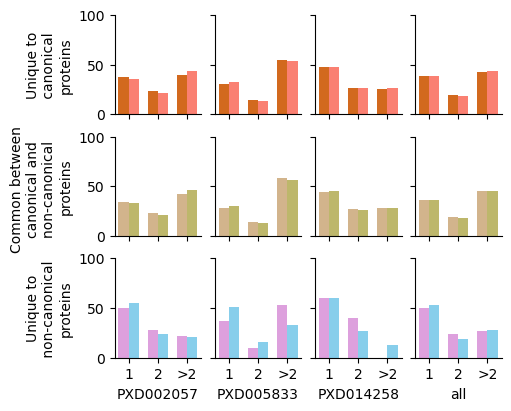

In [13]:
fig, ax = plt.subplots(3,4,layout='constrained',figsize=(5,4),sharex=True,sharey=True)
bar_width = 0.35
colors={PIPELINE_CL:{"Canon_unique":"chocolate",
              "NonCanon_unique":"plum",
              "Shared":"tan"},
       PIPELINE_N:{"Canon_unique":"salmon",
              "NonCanon_unique":"skyblue",
              "Shared":"darkkhaki"}}
for i,peptide_class in enumerate(peptide_class_order):
    row_label=( "Unique to\n canonical \nproteins" if peptide_class=="Canon_unique" 
               else "Unique to\n non-canonical \nproteins" if peptide_class=="NonCanon_unique" 
               else "Common between \ncanonical and \nnon-canonical \nproteins")
    group=data.groupby("peptide_class").get_group(peptide_class)
    for j,(PXD,group_pxd) in enumerate(group.groupby("dataset")):
        pivot_df = group_pxd.pivot(index='n_samp', columns='pipeline', values='percent')

        # Pivot both percent and count values
        pivot_percent = group_pxd.pivot(index='n_samp', columns='pipeline', values='percent')
        pivot_count = group_pxd.pivot(index='n_samp', columns='pipeline', values='value')
        x = np.arange(len(pivot_df.index))  # positions for "value" groups
        # Plot each pipeline's bars
        for m, pipeline in enumerate(pivot_percent.columns):
            bar_positions = x + m * bar_width
            bar_heights = pivot_percent[pipeline]
            ax[i, j].bar(bar_positions, bar_heights, width=bar_width, label=pipeline, color=colors[pipeline][peptide_class])
            
            # Annotate absolute counts
            #for xpos, yval, count_val in zip(bar_positions, bar_heights, pivot_count[pipeline]):
            #    ax[i, j].text(xpos, yval + 1, str(int(count_val)), ha='center', va='bottom', fontsize=8)
        
        # Set x-ticks and labels
        ax[i,j].set_ylim(0,100)
        ax[i,j].set_xticks(x + bar_width / 2)
        ax[i,j].set_xticklabels(["1","2",">2"])
        if i==2: ax[i, j].set_xlabel(PXD)
        if j==0: ax[i,j].set_ylabel(row_label)  
        spines = ["top","right"]
        for s in spines:
            ax[i,j].spines[s].set_visible(False) 
            
        j+=1

plt.savefig(f"{plot_dir}/pep_repr.svg", format='svg', bbox_inches = 'tight')

### PSM per peptide by peptide class

In [14]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_pepcl_psm_frq.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_pepcl_psm_frq.pkl")
# concat
data = pd.concat([data_cl, data_n])
#remove decoy
data = data[data['peptide_class']!='decoy']
# map subclass by class
data['peptide_class'] = data['peptide_class'].map(peptide_subclasses)
#aggrigate bars hight
data2=pd.DataFrame(columns=["pipeline","peptide_class","bin_size","bin"])
for (pipl,pcl,bin),group in data.groupby(["pipeline","peptide_class","bin"]):
    row=[pipl,pcl,len(group),bin]
    data2.loc[len(data2)]=row

/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)
/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


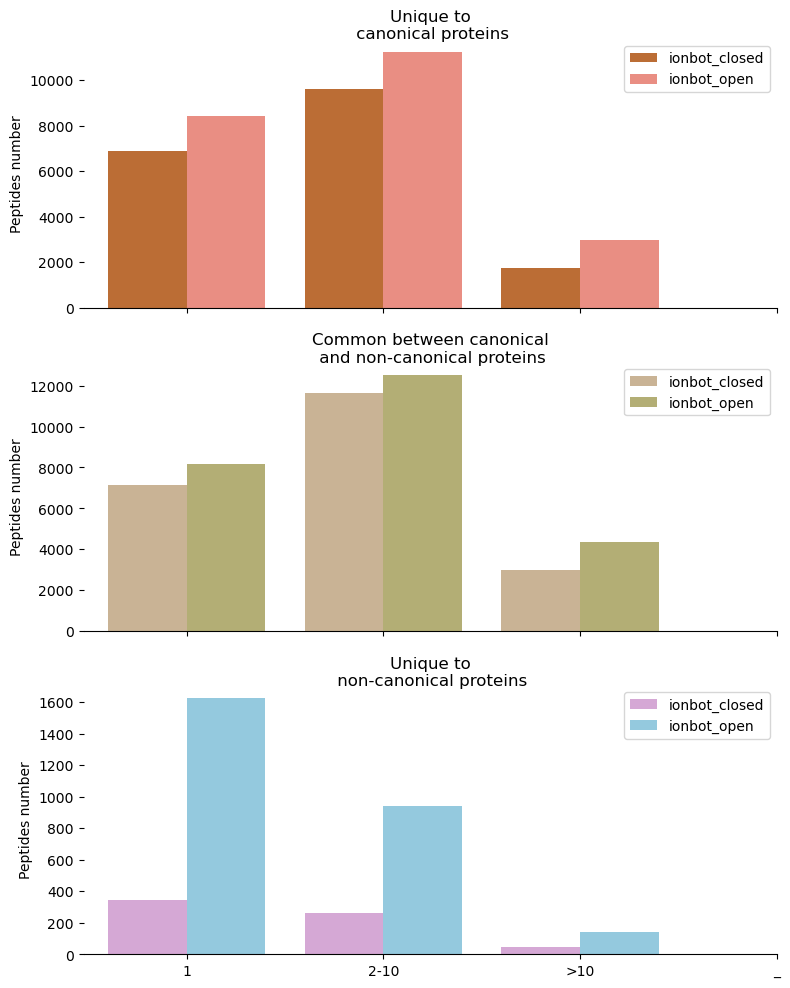

In [15]:
# Define figure and axes: 3 rows, 1 column (adjust cols/rows as you wish)
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Iterate through peptide classes and their corresponding subplot axis
for i, (cl, ax) in enumerate(zip(peptide_class_order, axes)):
    attribute = (
        "canon_unique" if cl == "Canon_unique"
        else "noncanon_unique" if cl == "NonCanon_unique"
        else "shared"
    )
    legend_title = (
        "Unique to\n canonical proteins" if cl == "Canon_unique"
        else "Unique to\n non-canonical proteins" if cl == "NonCanon_unique"
        else "Common between canonical\n and non-canonical proteins"
    )

    # Plot directly on the provided subplot axis
    sns.barplot(
        data=data2[data2.peptide_class == cl],
        x="bin", y="bin_size", hue="pipeline",
        palette={
            PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{attribute}"],
            PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{attribute}"]
        },
        alpha=1,
        ax=ax
    )

    # Customize axis labels and ticks
    if i == 2:
        ax.set_xticks(range(4))
        ax.set_xticklabels(["1", "2-10", ">10","_"])
        ax.set_xlabel("PSMs per peptide")
    else:
        ax.set_xlabel("")
        ax.set_xticks([])

    ax.set_ylabel("Peptides number")
    ax.set_title(legend_title, y=0.97)

    # Remove spines and style
    sns.despine(ax=ax, left=True)
    ax.legend_.set_title("")  # remove legend title

# Adjust layout to fit everything nicely
plt.tight_layout()

plt.savefig(f"{plot_dir}/psm_per_pep_by_pepcl.svg", format='svg', bbox_inches = 'tight')

### Proteins by database search

In [16]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_bysearch_proteins.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_bysearch_proteins.pkl")
# concat
data = pd.concat([data_cl, data_n])
#preprocess
data["group"]=data.group.map({'singletons': 'unambiguous',"indistinguishable proteins":"indistinguishable proteins"})
data["database"]=data.database.map(database_map)
data["database"] = data["database"].astype("category")
data.database = data.database.cat.set_categories(database_title_order)
data.sort_values(["database"],inplace=True)

In [17]:
fig = px.bar(data, x="database", y="value", color="group", facet_col="pipeline", labels={"database":"","value":"proteins number"},
            text_auto=True)
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    bargap=0, width=900, height=400
)
fig.write_image(f"{plot_dir}/prot_by_db.svg",format='svg')

### Proteins reproducability by group

In [18]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_prot_reproduce_PXD_{PIPELINE_CL_LW}_protcl_counts.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_prot_reproduce_PXD_{PIPELINE_N_LW}_protcl_counts.pkl")
# concat
data = pd.concat([data_cl, data_n])
# correct dataset
data['dataset'] = data['dataset'].str.replace('.v0.11.4','')
# percent
data['percent'] = (
    data.groupby(['pipeline', 'dataset',  'search_database','level'])['value']
    .transform(lambda x: 100 * x / x.sum())
)

#### by dataset

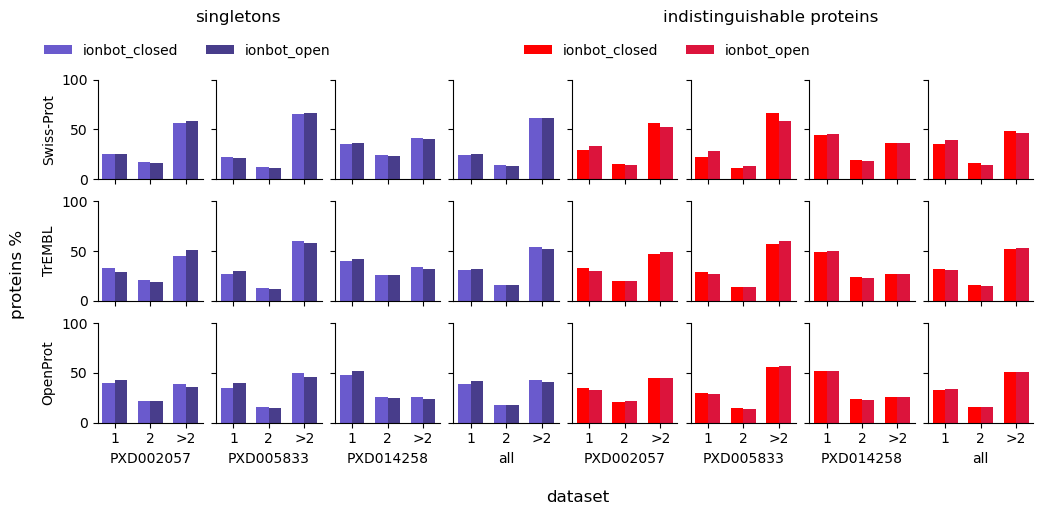

In [19]:
fig, ax = plt.subplots(3,8,layout='constrained',figsize=(10,4),sharex=True,sharey=True)
bar_width = 0.35
group_positions = [1.5, 5.5]
colors={PIPELINE_CL:{"singletons":"slateblue","indistinguishable proteins":"red"},
        PIPELINE_N:{"singletons":"darkslateblue","indistinguishable proteins":"crimson"}}
handles1 = [
    Patch(facecolor=colors[PIPELINE_CL]["singletons"], label=PIPELINE_CL),
    Patch(facecolor=colors[PIPELINE_N]["singletons"], label=PIPELINE_N)]
handles2 = [
    Patch(facecolor=colors[PIPELINE_CL]["indistinguishable proteins"], label=PIPELINE_CL),
    Patch(facecolor=colors[PIPELINE_N]["indistinguishable proteins"], label=PIPELINE_N)]

for jj,level_list in enumerate(["singletons","indistinguishable proteins"]):
    for i,database in enumerate(database_order):
        row_label=database_map[database]
        group=data.groupby(["search_database",'level']).get_group((database,level_list))
        j=jj*4
        for PXD,group_pxd in group.groupby("dataset"):
            pivot_df = group_pxd.pivot(index='n_samp', columns='pipeline', values='percent')
            x = np.arange(len(pivot_df.index))  # positions for "value" groups

            # Plot each pipeline as a separate bar set
            for m, pipeline in enumerate(pivot_df.columns):
                ax[i,j].bar(x + m * bar_width, pivot_df[pipeline], width=bar_width, label=pipeline,color=colors[pipeline][level_list])
            
            # Set x-ticks and labels
            ax[i,j].set_ylim(0,100)
            ax[i,j].set_xticks(x + bar_width / 2)
            ax[i,j].set_xticklabels(["1","2",">2"])
            if i==2: ax[i, j].set_xlabel(PXD)
            if j==0: ax[i,j].set_ylabel(row_label)  
            spines = ["top","right"]
            for s in spines:
                ax[i,j].spines[s].set_visible(False) 
                

            j+=1
    #titles
    group_label= level_list
    fig.text(
            x=group_positions[jj] / 7.5, 
            y=1.15,             
            s=group_label,
            ha='center',
            va='top',
            fontsize=12,
        )
#xlabel
fig.text(x=0.54,y=-0.05,s="dataset",ha='center',va='top',fontsize=12,)
#ylabel
fig.text(x=-0.02,y=0.6,s="proteins %",ha='center',va='top',fontsize=12,rotation=90)
#legend
fig.legend(
    handles=handles1, 
    loc='lower center', 
    bbox_to_anchor=(0.15, 1),  # Adjust for above the plot
    ncol=2, fontsize=10, frameon=False
)
fig.legend(
    handles=handles2, 
    loc='lower center', 
    bbox_to_anchor=(0.63, 1), 
    ncol=2, fontsize=10, frameon=False
)

#### only all

indistinguishable proteins
singletons


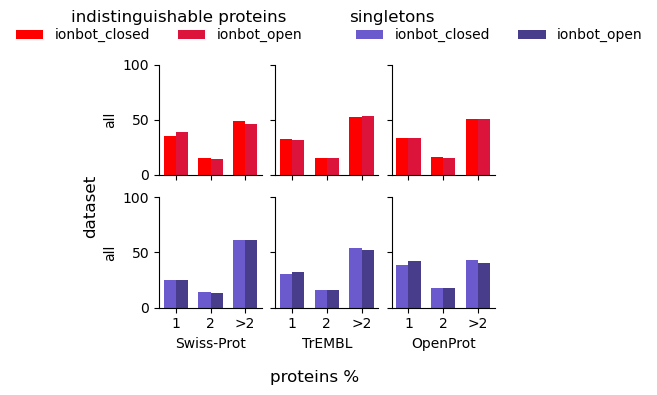

In [20]:
fig, ax = plt.subplots(2,3,layout='constrained',figsize=(4,3),sharex=True,sharey=True)
bar_width = 0.35
group_positions = [1.5, 5.5]
colors={PIPELINE_CL:{"singletons":"slateblue","indistinguishable proteins":"red"},
        PIPELINE_N:{"singletons":"darkslateblue","indistinguishable proteins":"crimson"}}
handles1 = [
    Patch(facecolor=colors[PIPELINE_CL]["indistinguishable proteins"], label=PIPELINE_CL),
    Patch(facecolor=colors[PIPELINE_N]["indistinguishable proteins"], label=PIPELINE_N)]
handles2 = [
    Patch(facecolor=colors[PIPELINE_CL]["singletons"], label=PIPELINE_CL),
    Patch(facecolor=colors[PIPELINE_N]["singletons"], label=PIPELINE_N)]

for jj,database in enumerate(database_order):
    for i,level_list in enumerate(["indistinguishable proteins","singletons"]):
        row_label=database_map[database]
        group=data[data['dataset']=='all'].groupby(["search_database",'level']).get_group((database,level_list))
        j=jj
        for PXD,group_pxd in group.groupby("dataset"):
            pivot_df = group_pxd.pivot(index='n_samp', columns='pipeline', values='percent')
            x = np.arange(len(pivot_df.index))  # positions for "value" groups

            # Plot each pipeline as a separate bar set
            for m, pipeline in enumerate(pivot_df.columns):
                ax[i,j].bar(x + m * bar_width, pivot_df[pipeline], width=bar_width, label=pipeline,color=colors[pipeline][level_list])
            
            # Set x-ticks and labels
            ax[i,j].set_ylim(0,100)
            ax[i,j].set_xticks(x + bar_width / 2)
            ax[i,j].set_xticklabels(["1","2",">2"])
            if i==1: ax[i, j].set_xlabel(row_label)
            if j==0: ax[i,j].set_ylabel(PXD)  
            spines = ["top","right"]
            for s in spines:
                ax[i,j].spines[s].set_visible(False) 
                

            j+=1
for i,level_list in enumerate(["indistinguishable proteins","singletons"]):
    #titles
    group_label= level_list
    print(group_label)
    fig.text( 
            x=group_positions[i] / 7.5,
            y=1.15,             
            s=group_label,
            ha='center',
            va='top',
            fontsize=12,
        )
#xlabel
fig.text(x=0.54,y=-0.05,s="proteins %",ha='center',va='top',fontsize=12,)
#ylabel
fig.text(x=-0.02,y=0.6,s="dataset",ha='center',va='top',fontsize=12,rotation=90)
#legend
fig.legend(
    handles=handles1, 
    loc='lower center', 
    bbox_to_anchor=(0.15, 1),  # Adjust for above the plot
    ncol=2, fontsize=10, frameon=False
)
fig.legend(
    handles=handles2, 
    loc='lower center', 
    bbox_to_anchor=(1, 1), 
    ncol=2, fontsize=10, frameon=False
)

plt.savefig(f"{plot_dir}/prot_repr_all_dataset.svg", format='svg', bbox_inches = 'tight')

### Number of proteins per protein class

In [21]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_byprotclass_proteins.pkl")
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_byprotclass_proteins.pkl")
# concat
data = pd.concat([data_cl, data_n])
# only op
data = data[data['search'] == 'openprot']
# preprocess
data["group"]=data.group.map({'singletons': 'unambiguous',"indistinguishable proteins":"indistinguishable proteins"})
data["protein_class"]=data.protein_class.map({'Canonical': 'Canonical proteins', 'NonCanonical': 'Non-canonical proteins'})
data.sort_values("protein_class",inplace=True)

In [22]:
data

,pipeline,search,protein_class,group,value
2,ionbot_closed,openprot,Canonical proteins,unambiguous,1064
3,ionbot_closed,openprot,Canonical proteins,indistinguishable proteins,32877
2,ionbot_open,openprot,Canonical proteins,unambiguous,1165
3,ionbot_open,openprot,Canonical proteins,indistinguishable proteins,31880
4,ionbot_closed,openprot,Non-canonical proteins,unambiguous,109
5,ionbot_closed,openprot,Non-canonical proteins,indistinguishable proteins,0
4,ionbot_open,openprot,Non-canonical proteins,unambiguous,420
5,ionbot_open,openprot,Non-canonical proteins,indistinguishable proteins,0


In [23]:
for protein_class, df in data.groupby('protein_class'):
    save_label = 'canon' if protein_class == 'Canonical proteins' else 'noncanon'
    fig = px.bar(df, x="protein_class", y="value", color="group", facet_col="pipeline", labels={"protein_class":"","value":"proteins number"},
            text_auto=True)
    fig.update_layout(
        plot_bgcolor="white",
        paper_bgcolor="white",
        bargap=0, width=600, height=300
    )
    fig.write_image(f"{plot_dir}/prot_by_protcl_{save_label}.svg",format='svg')

### PSM per protein

In [24]:
from matplotlib.ticker import FuncFormatter
# Custom formatter function for y-axis
def k_formatter(x, pos):
    """Format large numbers as 1k, 2.5k, etc."""
    if x >= 1000:
        return f"{x/1000:.0f}k" if x % 1000 == 0 else f"{x/1000:.1f}k"
    else:
        return f"{int(x)}"

In [25]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_psm_per_prot.pkl"); data_cl['pipeline'] = PIPELINE_CL
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_psm_per_prot.pkl"); data_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([data_cl, data_n])
# bin
bins = [[0],[1],list(range(2,10+1)),list(range(10,10000))]
bins_i = [(i,b) for i, b in enumerate(bins)]
data['bin'] = data['value'].apply(lambda x: [i for i,b in bins_i if x in b][0])
# ensure that only present proteins are included
data = data[data['bin']>0]
# sum proteins
data = data.groupby(['pipeline','level','protein_class','bin']).apply(len).to_frame().reset_index().rename(columns={0:'bin_size'})

In [26]:
color_map = {
    PIPELINE_CL:{
        "Canonical": {
            "Singleton": project_palette2[f"{PIPELINE_CL}_canon_unique"],
            "Group": project_palette2[f"{PIPELINE_CL}_shared"],
        },
        "NonCanonical": {
            "Singleton": project_palette2[f"{PIPELINE_CL}_noncanon_unique"],
            "Group": project_palette2[f"{PIPELINE_CL}_shared"],
        }
    },
    PIPELINE_N:{
        "Canonical": {
            "Singleton": project_palette2[f"{PIPELINE_N_NAME}_canon_unique"],
            "Group": project_palette2[f"{PIPELINE_N_NAME}_shared"],
        },
        "NonCanonical": {
            "Singleton": project_palette2[f"{PIPELINE_N_NAME}_noncanon_unique"],
            "Group": project_palette2[f"{PIPELINE_N_NAME}_shared"],
        }
    },
}

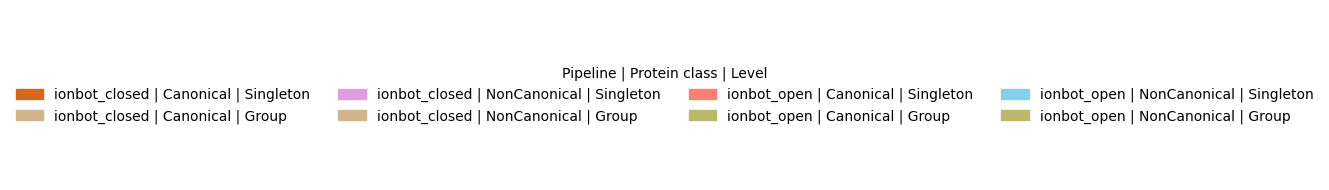

In [27]:
#legend too big - plot seperetly

from matplotlib.patches import Patch

# Prepare legend handles (as you already have)
legend_handles = []
for pipeline in [PIPELINE_CL, PIPELINE_N]:
    for protein_class in ["Canonical", "NonCanonical"]:
        for level, color in color_map[pipeline][protein_class].items():
            label = f"{pipeline} | {protein_class} | {level}"
            legend_handles.append(Patch(color=color, label=label))

# Create a new figure for the legend only
fig_legend = plt.figure(figsize=(8, 2))
ax = fig_legend.add_subplot(111)
ax.axis('off')  # no axes, blank figure

# Add legend to this figure
fig_legend.legend(
    handles=legend_handles,
    loc='center',
    ncol=4,  # adjust number of columns for readability
    title="Pipeline | Protein class | Level",
    frameon=False
)

plt.tight_layout()
plt.show()


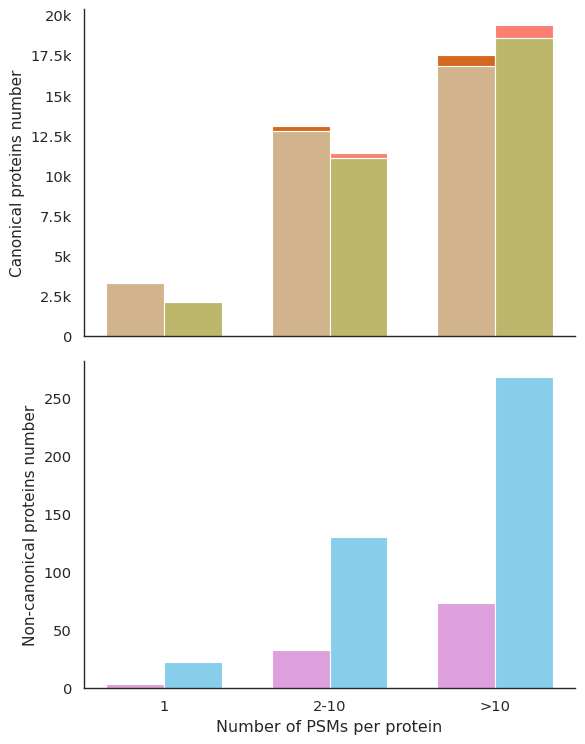

In [28]:
sns.set_theme(style="white", context="paper", font_scale=1.2)

# Ensure consistent order
protein_classes = sorted(data['protein_class'].unique())
bins = [1,2,3]
levels = sorted(data['level'].unique())
pipelines = sorted(data['pipeline'].unique())

fig, axes = plt.subplots(
    nrows=len(protein_classes),
    ncols=1,
    figsize=(6, 4 * len(protein_classes)),
    sharex=True,
    sharey=False,
)

if len(protein_classes) == 1:
    axes = [axes]

bar_width = 0.35  # width of each pipeline bar
gap = 0.15        # gap between bin groups

for i, protein_class in enumerate(protein_classes):
    ax = axes[i]

    # X positions for each bin group
    x_base = np.arange(len(bins))
    total_bar_width = bar_width * len(pipelines)
    offsets = np.linspace(-total_bar_width/2 + bar_width/2, total_bar_width/2 - bar_width/2, len(pipelines))

    for j, pipeline in enumerate(pipelines):
        df_subset = data[(data['pipeline']==pipeline) & (data['protein_class']==protein_class)]
        # Pivot: index=bin, columns=level, values=sum(bin_size)
        df_pivot = df_subset.pivot_table(index='bin', columns='level', values='bin_size', aggfunc='sum').reindex(index=bins, columns=levels, fill_value=0)

        bottom = np.zeros(len(df_pivot))
        for level in df_pivot.columns:
            heights = df_pivot[level].values
            ax.bar(
                x_base + offsets[j],
                heights,
                bottom=bottom,
                width=bar_width,
                color=[color_map[pipeline][protein_class][level]]*len(heights),
                label=f"{pipeline} | {level}" if i==0 else None
            )
            bottom += heights

    # Axis formatting
    ax.set_xticks(x_base)
    ax.set_xticklabels(['1', '2-10', '>10'])
    ax.set_xlabel("Number of PSMs per protein" if i == len(protein_classes)-1 else "")
    ax.set_ylabel(f"{protein_class if protein_class=='Canonical' else 'Non-canonical'} proteins number", fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(k_formatter))
    sns.despine(ax=ax)

# Shared legend
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='lower center', ncol=len(labels), title="Pipeline | Level")

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(f"{plot_dir}/psm_per_prot_by_pepcl.svg", format='svg', bbox_inches = 'tight')

### Peptide per prot

In [29]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_pep_per_prot.pkl"); data_cl['pipeline'] = PIPELINE_CL
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_pep_per_prot.pkl"); data_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([data_cl, data_n])
# bin
bins = [[0],[1],list(range(2,10+1)),list(range(10,10000))]
bins_i = [(i,b) for i, b in enumerate(bins)]
data['bin'] = data['value'].apply(lambda x: [i for i,b in bins_i if x in b][0])
# ensure that only present proteins are included
data = data[data['bin']>0]
# sum proteins
data = data.groupby(['pipeline','level','protein_class','bin']).apply(len).to_frame().reset_index().rename(columns={0:'bin_size'})

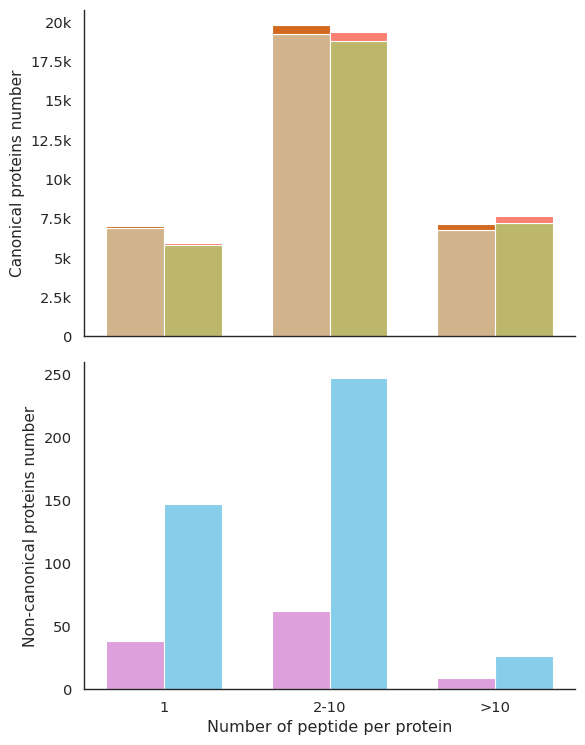

In [30]:
sns.set_theme(style="white", context="paper", font_scale=1.2)

# Ensure consistent order
protein_classes = sorted(data['protein_class'].unique())
bins = [1,2,3]
levels = sorted(data['level'].unique())
pipelines = sorted(data['pipeline'].unique())

fig, axes = plt.subplots(
    nrows=len(protein_classes),
    ncols=1,
    figsize=(6, 4 * len(protein_classes)),
    sharex=True,
    sharey=False,
)

if len(protein_classes) == 1:
    axes = [axes]

bar_width = 0.35  # width of each pipeline bar
gap = 0.15        # gap between bin groups

for i, protein_class in enumerate(protein_classes):
    ax = axes[i]

    # X positions for each bin group
    x_base = np.arange(len(bins))
    total_bar_width = bar_width * len(pipelines)
    offsets = np.linspace(-total_bar_width/2 + bar_width/2, total_bar_width/2 - bar_width/2, len(pipelines))

    for j, pipeline in enumerate(pipelines):
        df_subset = data[(data['pipeline']==pipeline) & (data['protein_class']==protein_class)]
        # Pivot: index=bin, columns=level, values=sum(bin_size)
        df_pivot = df_subset.pivot_table(index='bin', columns='level', values='bin_size', aggfunc='sum').reindex(index=bins, columns=levels, fill_value=0)

        bottom = np.zeros(len(df_pivot))
        for level in df_pivot.columns:
            heights = df_pivot[level].values
            ax.bar(
                x_base + offsets[j],
                heights,
                bottom=bottom,
                width=bar_width,
                color=[color_map[pipeline][protein_class][level]]*len(heights),
                label=f"{pipeline} | {level}" if i==0 else None
            )
            bottom += heights

    # Axis formatting
    ax.set_xticks(x_base)
    ax.set_xticklabels(['1', '2-10', '>10'])
    ax.set_xlabel("Number of peptide per protein" if i == len(protein_classes)-1 else "")
    ax.set_ylabel(f"{protein_class if protein_class=='Canonical' else 'Non-canonical'} proteins number", fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(k_formatter))
    sns.despine(ax=ax)

# Shared legend
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='lower center', ncol=len(labels), title="Pipeline | Level")

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(f"{plot_dir}/pep_per_prot_by_pepcl.svg", format='svg', bbox_inches = 'tight')

### Protein unique sequence coverage

In [31]:
#load
data_cl = pd.read_pickle(f"{results_dir}/{PIPELINE_CL_LW}_unique_peptide_aa_coverege_df.pkl"); data_cl['pipeline'] = PIPELINE_CL
data_n = pd.read_pickle(f"{results_dir}/{PIPELINE_N_LW}_unique_peptide_aa_coverege_df.pkl"); data_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([data_cl, data_n])
# map subclass by class
data['peptide_class'] = data['peptide_class'].map(peptide_subclasses)

/tmp/ipykernel_72322/148251283.py:47: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



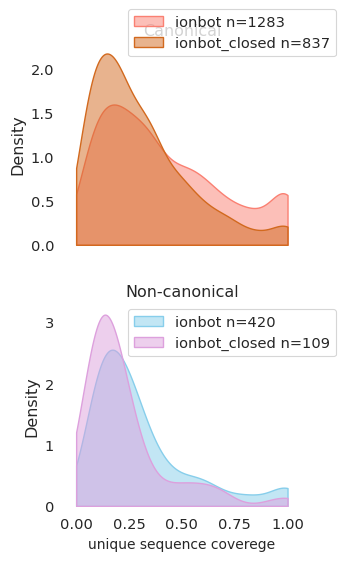

In [32]:
gs = (grid_spec.GridSpec(2,1))
gs.update(hspace= 0.3)
fig = plt.figure(figsize=(3,6))
i = 0
#creating empty list
ax_objs = []
for attribute in ["Canonical","Non-canonical"]:
    # creating new axes object and appending to ax_objs
    ax_objs.append(fig.add_subplot(gs[i:i+1, 0:]))

    color= "noncanon_unique" if attribute=="Non-canonical" else "canon_unique"
    peptide_class="NonCanon_unique" if attribute=="Non-canonical" else "Canon_unique"
    # plotting the distribution
    data1=data.loc[(data.peptide_class==peptide_class)&(data.pipeline==PIPELINE_N),'value']
    
    plot1 = sns.kdeplot(data1, ax=ax_objs[-1],clip=(0,1),
                        color=project_palette2[f"{PIPELINE_N_NAME}_{color}"], 
                        lw=1,label=f"{PIPELINE_N_NAME} n={len(data1)}",fill=True,alpha=0.5)
    
    data2=data.loc[(data.peptide_class==peptide_class)&(data.pipeline==PIPELINE_CL),'value']
    
    plot2 = sns.kdeplot(data2, ax=ax_objs[-1],clip=(0,1),
                        color=project_palette2[f"{PIPELINE_CL}_{color}"], 
                        lw=1,label=f"{PIPELINE_CL} n={len(data2)}",fill=True,alpha=0.5)

    # make background transparent
    rect = ax_objs[-1].patch
    rect.set_alpha(0)

    if i == 1:
        ax_objs[-1].set_xlabel("unique sequence coverege", fontsize=10)
    else:
        ax_objs[-1].set_xticklabels([])
        ax_objs[-1].set_xlabel("")
    
    spines = ["top","right","left","bottom"]
    for s in spines:
        ax_objs[-1].spines[s].set_visible(False)
    
    ax_objs[-1].set_title(attribute)
    if i==0: pos=(1.05,0.95)
    if i==1: pos=(1.05,0.45)
    ax_objs[-1].legend(bbox_to_anchor=pos,bbox_transform=fig.transFigure)

    i += 1

plt.tight_layout()

plt.savefig(f"{plot_dir}/proteotypic_pep_coverage.svg", format='svg', bbox_inches = 'tight')

In [33]:
#look at length of protein with proteotypic peptides - no difference now
#put this plots in the right top corner of coverege plots

In [34]:
OPfasta_file="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/concatenated-fastas/20241102-openprot-database_ionbot_db/concat.fasta"
input_file = open(OPfasta_file)
OPfasta = SeqIO.to_dict(SeqIO.parse(OPfasta_file, "fasta"))

In [35]:
# collect protein length
prot_len=[]
for (pipeline, peptide_class, protein), group in data.reset_index().groupby(['pipeline',"peptide_class",'index']):
    prot_len += [[pipeline, peptide_class, protein, len(str(OPfasta[protein].seq))]]
prot_len = pd.DataFrame(prot_len, columns=['pipeline',"peptide_class",'protein','prot_len'])

In [36]:
# % of singleton proteins <= 100 aa
prot_len.groupby(['pipeline',"peptide_class"]).apply(lambda x: (len(x[x['prot_len']<=100])/len(x))*100 )

pipeline       peptide_class  
ionbot_closed  Canon_unique        6.810036
               NonCanon_unique    41.284404
ionbot_open    Canon_unique        7.248636
               NonCanon_unique    42.142857
dtype: float64

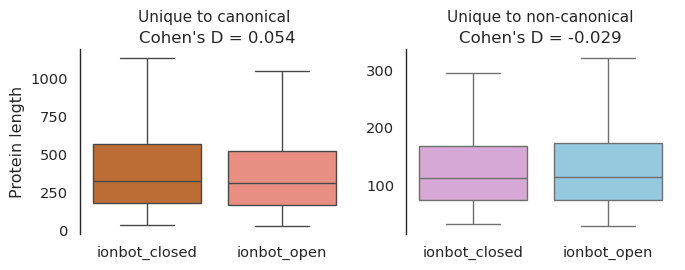

In [37]:
# Define order and figure
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

for i, peptide_class in enumerate(["Canon_unique", "NonCanon_unique"]):
    ax = axes[i]
    color = "noncanon_unique" if peptide_class == "NonCanon_unique" else "canon_unique"
    subset = prot_len[prot_len["peptide_class"] == peptide_class]
    
    # Calculate Cohen’s d
    c0 = subset[subset["pipeline"] == PIPELINE_CL]["prot_len"].tolist()
    c1 = subset[subset["pipeline"] == PIPELINE_N]["prot_len"].tolist()
    cohens_d = (np.mean(c0) - np.mean(c1)) / np.sqrt((np.std(c0) ** 2 + np.std(c1) ** 2) / 2)

    # Boxplot
    sns.boxplot(
        x="pipeline", y="prot_len", hue="pipeline", data=subset, showfliers=False,
        ax=ax,
        palette={
            PIPELINE_CL: project_palette2[f"{PIPELINE_CL}_{color}"],
            PIPELINE_N: project_palette2[f"{PIPELINE_N_NAME}_{color}"],
        },
    )
    sns.despine(ax=ax, bottom=True)
    
    # Axis labels
    ax.set_xlabel("")
    if i == 0:
        ax.set_ylabel("Protein length")
    else:
        ax.set_ylabel("")
    
    # Add title & annotation
    title = "Unique to canonical" if peptide_class == "Canon_unique" else "Unique to non-canonical"
    ax.set_title(title, fontsize=11, pad=20)
    ax.text(
        0.8, 1.1, f"Cohen's D = {round(cohens_d, 3)}",
        transform=ax.transAxes, fontsize=12, ha="right", va="top"
    )
    
    # Remove duplicate legends

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(f"{plot_dir}/singleton_prot_len.svg", format='svg', bbox_inches = 'tight')

### S: Peptides' class switch between pipelines

In [38]:
import ast
import tpp_preprocess as tpp

In [39]:
# classic pipeline PSM

processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# get processed files
processed_paths_cl=dt.list_files(processed_dir)
# leave only non-entrapment and closed search, only search files
tmp = processed_paths_cl.copy()
for parent, files in processed_paths_cl.items():
    if '.v0.11.4' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths_cl = tmp
psm_filt_cl = []
for parent, files in processed_paths_cl.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output.csv': #-closed-db
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-2])
            search_database = parent.split('/')[-1].split('-')[-1] ;dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file), low_memory=False)
            #data['spectrum_file'] = spectrum_file ; 
            data['search_database'] = search_database ; data['dataset'] = dataset
            # from Enrico
            # fixes issue with some files being .RAW and other being .raw
            data.spectrum_file = data.spectrum_file.apply(lambda x: x.split('.')[0])
            # in some mgf files the 'spectrum title' includes the file name, making the spectrum title unique.
            # when the file name is NOT included, spectrum titles are NOT unique, and this can mess up some analysis.
            data.spectrum_title = data.spectrum_file + ':' + data.spectrum_title.apply(lambda x: x.split(':')[-1])
            psm_filt_cl += [data]
psm_filt_cl = pd.concat(psm_filt_cl)
psm_filt_cl = psm_filt_cl[(psm_filt_cl['q.value'] <= 0.01)&(psm_filt_cl['isCanonical'] != 'Contam')]
psm_filt_cl['proteins'] = psm_filt_cl['proteins'].apply(lambda x: x.split(';'))
psm_filt_cl['isProteotypic'] = psm_filt_cl['proteins'].apply(lambda x: len(x)==1)
psm_filt_cl["peptide_class"]=psm_filt_cl["proteins"].apply(tpp.classify_peptide_tpp)

# new pipeline PSM
processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# get processed files
processed_paths_n=dt.list_files(processed_dir)
# leave only non-entrapment and closed search, only search files
# leave only non-entrapment and open search, only search files
tmp = processed_paths_n.copy()
for parent, files in processed_paths_n.items():
    if '-closed' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths_n = tmp
psm_filt_n = []
for parent, files in processed_paths_n.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output.csv': #-closed-db
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1] ; dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file), low_memory=False)
            #data['spectrum_file'] = spectrum_file ; 
            data['search_database'] = search_database ; data['dataset'] = dataset
            # from Enrico
            # fixes issue with some files being .RAW and other being .raw
            data.spectrum_file = data.spectrum_file.apply(lambda x: x.split('.')[0])
            # in some mgf files the 'spectrum title' includes the file name, making the spectrum title unique.
            # when the file name is NOT included, spectrum titles are NOT unique, and this can mess up some analysis.
            data.spectrum_title = data.spectrum_file + ':' + data.spectrum_title.apply(lambda x: x.split(':')[-1])
            psm_filt_n += [data]
psm_filt_n = pd.concat(psm_filt_n)
psm_filt_n = psm_filt_n[(psm_filt_n['q.value'] < 0.01)&(psm_filt_n['isCanonical'] != 'Contam')]
psm_filt_n['proteins'] = psm_filt_n['proteins'].apply(lambda x: x.split(';'))
psm_filt_n['isProteotypic'] = psm_filt_n['proteins'].apply(lambda x: len(x)==1)
psm_filt_n["peptide_class"]=psm_filt_n["proteins"].apply(tpp.classify_peptide_tpp)

# select openprot
psm_filt_cl = psm_filt_cl[psm_filt_cl['search_database'] == 'openprot']
psm_filt_n = psm_filt_n[psm_filt_n['search_database'] == 'openprot']

20251015-oui-discovery-ionbot-results/
    PXD005833.v0.11.4/
        openprot-x-trembl-filt-global-outerjoin.csv
        PXD005833-opensearch-x-closedsearch-filt-global.csv.gz
        Metadata_PXD005833.v0.11.4-openprot.txt
        ID-rate-df-filt-hybrid.csv
        ID-rate-df-filt-False.csv
        Metadata_PXD005833.v0.11.4-canon.txt
        Metadata_PXD005833.v0.11.4-trembl.txt
        PXD005833-opensearch-x-closedsearch-filt-global-outerjoin.csv.gz
        openprot-x-trembl-filt-global.csv
        ID-rate-df-filt-custom.csv
        ID-rate-df-filt-global.csv
        ID-rate-df-filt-groupwalk.csv
        PXD005833.v0.11.4-canon/
            PXD005833.v0.11.4-canon-combined-features.csv.gz
            combined-results-w-qvalues.csv.gz
            AM15-canon/
                ionbot.first.proteins.csv
                sample-protein-inference-input.pout
                group-walk-output-peptide-vv.csv
                ionbot.features.csv
                ionbot.first.csv
                

In [40]:
#create a common key that identifies spectra
psm_filt_cl['scan_name'] = psm_filt_cl['scan'].astype(str) + '_' + psm_filt_cl['spectrum_file'] + '_' + psm_filt_cl['spectrum_title']
psm_filt_n['scan_name'] = psm_filt_n['scan'].astype(str) + '_' + psm_filt_n['spectrum_file'] + '_' + psm_filt_n['spectrum_title']

In [41]:
len(psm_filt_cl), len(psm_filt_n)

(202508, 323529)

In [42]:
# combine
psm_filt_comb = pd.merge(psm_filt_cl, psm_filt_n, how="outer",on="scan_name", suffixes=(f'_{PIPELINE_CL}', f'_{PIPELINE_N}'))

In [43]:
#hw many are in common - Flase-False

(psm_filt_comb[[f"spectrum_file_{PIPELINE_CL}",f"spectrum_file_{PIPELINE_N}"]].isna().value_counts()/len(psm_filt_comb))*100

spectrum_file_ionbot_closed  spectrum_file_ionbot_open
False                        False                        54.091787
True                         False                        40.679421
False                        True                          5.228793
Name: count, dtype: float64

In [44]:
#switch, others unidentified in either search

ann_data=psm_filt_comb[[f"peptide_class_{PIPELINE_CL}",f"peptide_class_{PIPELINE_N}"]].value_counts()

In [45]:
nodes=["unidentified","Decoy","unique_to_Noncanon",'shared_in_Noncanon',"unique_to_Canon",'shared_in_Canon','shared_btw_can_noncan']
nodes_names=[f"{PIPELINE_CL}:"+x for x in nodes]+[f"{PIPELINE_N}:"+x for x in nodes]
source_target_nodes=list(itertools.combinations(nodes_names, 2))
#filter out source-source, target-target
source_target_nodes=[n for n in source_target_nodes if n[0].split(":")[0]!=n[1].split(":")[0]]
#corresponding indx
source_target_indx=[(nodes.index(n[0].split(":")[1]),nodes.index(n[1].split(":")[1])+len(nodes)) for n in source_target_nodes]

In [46]:
#fill values
sankey_data=pd.DataFrame({"source_name": [n[0].split(":")[1] for n in source_target_nodes],
                          "target_name": [n[1].split(":")[1] for n in source_target_nodes],
                         "link_source":[i[0] for i in source_target_indx],
                         "link_target":[i[1] for i in source_target_indx],
                         "link_value":[ann_data[(n[0].split(":")[1],  n[1].split(":")[1])] if (n[0].split(":")[1],  n[1].split(":")[1]) in ann_data.index.tolist() else np.nan for n in source_target_nodes ]
                          }
                        )

In [47]:
#fill where PIPELINE_CL unidentified
#sankey_data[sankey_data.link_value.isna()]
a=psm_filt_comb[psm_filt_comb[f"spectrum_file_{PIPELINE_CL}"].isna()][f"peptide_class_{PIPELINE_N}"].value_counts()
b=sankey_data.loc[(sankey_data.link_value.isna())&(sankey_data.source_name=="unidentified")]
b['link_value'] = b['target_name'].map(a.to_dict())
sankey_data.loc[(sankey_data.link_value.isna())&(sankey_data.source_name=="unidentified")]=b
#Fill where ionbot is unidentified
a=psm_filt_comb[psm_filt_comb[f"spectrum_file_{PIPELINE_N}"].isna()][f"peptide_class_{PIPELINE_CL}"].value_counts()
b=sankey_data.loc[(sankey_data.link_value.isna())&(sankey_data.target_name=="unidentified")]
b['link_value'] = b['source_name'].map(a.to_dict())
sankey_data.loc[(sankey_data.link_value.isna())&(sankey_data.target_name=="unidentified")]=b

/tmp/ipykernel_72322/2732165016.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_72322/2732165016.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



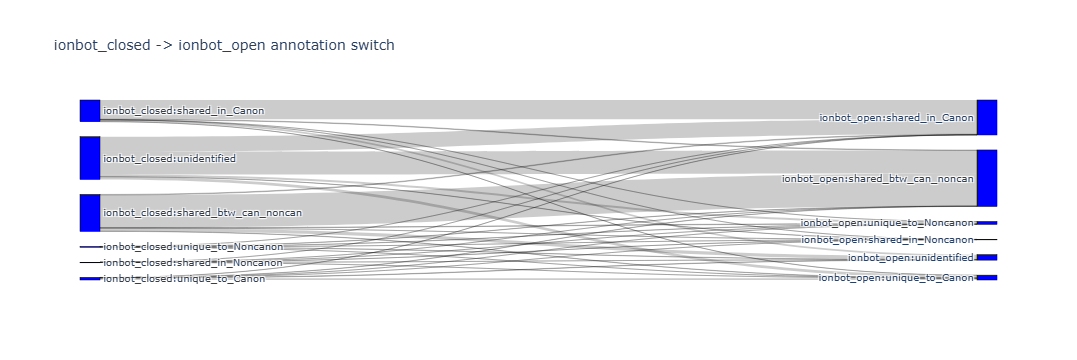

In [48]:
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = nodes_names,
      color = "blue"
    ),
    link = dict(
      source = sankey_data.link_source.tolist(),
      target = sankey_data.link_target.tolist(),
      value = sankey_data.link_value.tolist()
  ))])

fig.update_layout(title_text=f"{PIPELINE_CL} -> {PIPELINE_N} annotation switch", font_size=10)
#fig.write_image(f".svg")
fig.show()

#### plot like Enrico

In [233]:
#From Enrico, modified
def define_colors(x):
    x=x.split(":")[1]
    if x.startswith('Canonical'):
        return mypalette[0]
    elif x.startswith('NonCanonical'):
        return mypalette[1]
    elif x.startswith('Unidentified'):
        return mypalette[-2]
    elif x.startswith('Decoy'):
        return mypalette[-4]
        
map_enrico_peptide_class={i:"Canonical" if "_Canon" in i or "shared_btw_" in i else "NonCanonical" for k,v in peptide_classes.items() for i in v}
map_enrico_peptide_class.update({"Decoy":"Decoy","decoy":"Decoy"})
map_enrico_ptm={"Unmodified":"Unmodified/Expected","Expected":"Unmodified/Expected","Unexpected":"Unexpected"}


In [234]:
data=psm_filt_comb.copy(deep=True)
# correct peptide class as it omits decoy
data.loc[data[f"database_{PIPELINE_CL}"] == 'D',f"peptide_class_{PIPELINE_CL}"] = 'Decoy'
data.loc[data[f"database_{PIPELINE_N}"] == 'D',f"peptide_class_{PIPELINE_N}"] = 'Decoy'
# map new names
data[f"peptide_class_mapped_{PIPELINE_CL}"]=data[f"peptide_class_{PIPELINE_CL}"].map(map_enrico_peptide_class)
data[f"peptide_class_mapped_{PIPELINE_N}"]=data[f"peptide_class_{PIPELINE_N}"].map(map_enrico_peptide_class)
data[f"peptide_class_mapped_{PIPELINE_CL}"].fillna("Unidentified",inplace=True)
data[f"peptide_class_mapped_{PIPELINE_N}"].fillna("Unidentified",inplace=True)
# same category for unmodified and expected
data[f'isModified2_{PIPELINE_CL}'] = data[f'isModified_{PIPELINE_CL}'].map(map_enrico_ptm)
data[f'isModified2_{PIPELINE_N}'] = data[f'isModified_{PIPELINE_N}'].map(map_enrico_ptm)
data[f'isModified2_{PIPELINE_CL}'].fillna("Unidentified",inplace=True)
data[f'isModified2_{PIPELINE_N}'].fillna("Unidentified",inplace=True)
# join peptide class and modifications
data[f"peptide_class_mapped_isMod_{PIPELINE_CL}"] = data[f"peptide_class_mapped_{PIPELINE_CL}"] + '+' + data[f'isModified2_{PIPELINE_CL}']
data[f"peptide_class_mapped_isMod_{PIPELINE_N}"] = data[f"peptide_class_mapped_{PIPELINE_N}"] + '+' + data[f'isModified2_{PIPELINE_N}']
# correct decoy and unidentified (do not care about modifications)
data[f"peptide_class_mapped_isMod_{PIPELINE_CL}"]=data[f"peptide_class_mapped_isMod_{PIPELINE_CL}"].apply(lambda x: "Decoy" if "Decoy" in x 
                                                                                                else "Unidentified" if "Unidentified" in x
                                                                                               else x)
data[f"peptide_class_mapped_isMod_{PIPELINE_N}"]=data[f"peptide_class_mapped_isMod_{PIPELINE_N}"].apply(lambda x: "Decoy" if "Decoy" in x 
                                                                                                else "Unidentified" if "Unidentified" in x
                                                                                               else x)

In [51]:
enr_sankey_data=pd.DataFrame(data[[f"peptide_class_mapped_isMod_{PIPELINE_CL}",f"peptide_class_mapped_isMod_{PIPELINE_N}"]].value_counts())
enr_sankey_data.reset_index(inplace=True)
enr_sankey_data.columns=["source_name","target_name","link_value"]
#
nodes_enr=data[f"peptide_class_mapped_isMod_{PIPELINE_N}"].unique().tolist()
nodes_names_enr=[f"{PIPELINE_CL}:"+x for x in nodes_enr]+[f"{PIPELINE_N}:"+x for x in nodes_enr]
source_target_nodes_enr=list(itertools.combinations(nodes_names_enr, 2))
#filter out source-source, target-target
source_target_nodes_enr=[n for n in source_target_nodes_enr if n[0].split(":")[0]!=n[1].split(":")[0]]
#corresponding indx
source_target_indx_enr=[(nodes_enr.index(n[0].split(":")[1]),nodes_enr.index(n[1].split(":")[1])+len(nodes_enr)) for n in source_target_nodes_enr]
#
enr_sankey_data["link_source"]=enr_sankey_data.source_name.apply(lambda x: nodes_names_enr.index(f"{PIPELINE_CL}:"+x))
enr_sankey_data["link_target"]=enr_sankey_data.target_name.apply(lambda x: nodes_names_enr.index(f"{PIPELINE_N}:"+x))
#color
mypalette = sns.color_palette("Paired").as_hex()
labels_colors = {_:define_colors(_) for _ in nodes_names_enr}

In [52]:
labels_w_num=[
    f"{v.split(':')[1]} ({ 
        (
            int(enr_sankey_data[enr_sankey_data.source_name == v.split(':')[1]].link_value.sum()) 
            if v.split(':')[1] in enr_sankey_data.source_name.tolist() else 0
        )
        if v.startswith(PIPELINE_CL) else
        int(enr_sankey_data[enr_sankey_data.target_name == v.split(':')[1]].link_value.sum()) if v.split(':')[1] in enr_sankey_data.target_name.tolist()
        else 0
    })"
    for v in nodes_names_enr
]

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5), 
      label = labels_w_num, 
      color = list(labels_colors.values())
    ),
    link = dict(
      source = enr_sankey_data.link_source.tolist(),
      target = enr_sankey_data.link_target.tolist(),
      value = enr_sankey_data.link_value.tolist()
  ))])

fig.update_layout(title_text=f"{PIPELINE_CL} search (left) vs {PIPELINE_N} search (right)", font_size=10)
fig.update_layout(height=800, width=800,)
fig.write_image(f"{plot_dir}/pepcl_switch.svg")
fig.show()

SyntaxError: unterminated string literal (detected at line 2) (3235541406.py, line 2)

In [53]:
enr_sankey_data_zoom = enr_sankey_data[(enr_sankey_data.source_name.str.contains('NonCanonical'))|(enr_sankey_data.target_name.str.contains('NonCanonical'))]

In [54]:
labels_w_num=[
    f"{v.split(':')[1]} ({ 
        (
            int(enr_sankey_data_zoom[enr_sankey_data_zoom.source_name == v.split(':')[1]].link_value.sum()) 
            if v.split(':')[1] in enr_sankey_data_zoom.source_name.tolist() else 0
        )
        if v.startswith(PIPELINE_CL) else
        int(enr_sankey_data_zoom[enr_sankey_data_zoom.target_name == v.split(':')[1]].link_value.sum()) if v.split(':')[1] in enr_sankey_data_zoom.target_name.tolist()
        else 0
    })"
    for v in nodes_names_enr
]

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5), 
      label = labels_w_num, 
      color = list(labels_colors.values())
    ),
    link = dict(
      source = enr_sankey_data_zoom.link_source.tolist(),
      target = enr_sankey_data_zoom.link_target.tolist(),
      value = enr_sankey_data_zoom.link_value.tolist()
  ))])

fig.update_layout(title_text=f"{PIPELINE_CL} search (left) vs {PIPELINE_N} search (right)", font_size=10)
fig.update_layout(height=800, width=800,)
fig.write_image(f"{plot_dir}/pepcl_switch_zoom.svg")
fig.show()

SyntaxError: unterminated string literal (detected at line 2) (4098382274.py, line 2)

In [182]:
a = enr_sankey_data_zoom[(enr_sankey_data_zoom.source_name.str.contains('NonCanonical'))]
b = a[(a.target_name.str.startswith('Canonical'))|(a.target_name=='Unidentified')].link_value.sum()/a.link_value.sum()
print('closed search non-canonical X% filtered or match to canonical',b*100)

closed search non-canonical X% filtered or match to canonical 61.667382896433175


In [183]:
a = enr_sankey_data[(enr_sankey_data.source_name.str.contains('Canonical'))]
b = a[(a.target_name.str.startswith('NonCanonical'))].link_value.sum()/a.link_value.sum()
print('closed search canonical X% match to non-canonical',b*100)

closed search canonical X% match to non-canonical 1.3704714801191802


In [184]:
a = enr_sankey_data[(enr_sankey_data.source_name.str.contains('Unidentified'))]
b = a[(a.target_name.str.startswith('Canonical'))].link_value.sum()/a.link_value.sum()
print('closed search unidentified X% match to canonical',b*100)

closed search unidentified X% match to canonical 93.8705705294842


### Peptides position

In [97]:
import hpp_checker as hpp

In [98]:
# get the length of each protein

OPprot_len={key:len(value.seq) for key,value in OPfasta.items()}

In [99]:
#load peptides

processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# classical
# get processed files
processed_paths_cl=dt.list_files(processed_dir)
# leave only non-entrapment and closed search, only search files
tmp = processed_paths_cl.copy()
for parent, files in processed_paths_cl.items():
    if '.v0.11.4' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths_cl = tmp
pep_filt_cl = []
for parent, files in processed_paths_cl.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output-peptide-vv.csv' :
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-2])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            pep_filt_cl += [data]
pep_filt_cl = pd.concat(pep_filt_cl)
pep_filt_cl = pep_filt_cl[(pep_filt_cl['subset_max_rank'] == True)&(pep_filt_cl['isCanonical'] != 'Contam')]
pep_filt_cl['proteins'] = pep_filt_cl['proteins'].apply(lambda x: x.split(';'))
pep_filt_cl['isProteotypic'] = pep_filt_cl['proteins'].apply(lambda x: len(x)==1)
pep_filt_cl["peptide_class"]=pep_filt_cl["proteins"].apply(tpp.classify_peptide_tpp)

# new
# get processed files
processed_paths_n=dt.list_files(processed_dir)
# leave only non-entrapment and open search, only search files
tmp = processed_paths_n.copy()
for parent, files in processed_paths_n.items():
    if '-closed' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths_n = tmp
pep_filt_n = []
for parent, files in processed_paths_n.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output-peptide-vv.csv' :
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            pep_filt_n += [data]
pep_filt_n = pd.concat(pep_filt_n)
pep_filt_n = pep_filt_n[(pep_filt_n['subset_max_rank'] == True)&(pep_filt_n['isCanonical'] != 'Contam')]
pep_filt_n['proteins'] = pep_filt_n['proteins'].apply(lambda x: x.split(';'))
pep_filt_n['isProteotypic'] = pep_filt_n['proteins'].apply(lambda x: len(x)==1)
pep_filt_n["peptide_class"]=pep_filt_n["proteins"].apply(tpp.classify_peptide_tpp)

20251015-oui-discovery-ionbot-results/
    PXD005833.v0.11.4/
        openprot-x-trembl-filt-global-outerjoin.csv
        PXD005833-opensearch-x-closedsearch-filt-global.csv.gz
        Metadata_PXD005833.v0.11.4-openprot.txt
        ID-rate-df-filt-hybrid.csv
        ID-rate-df-filt-False.csv
        Metadata_PXD005833.v0.11.4-canon.txt
        Metadata_PXD005833.v0.11.4-trembl.txt
        PXD005833-opensearch-x-closedsearch-filt-global-outerjoin.csv.gz
        openprot-x-trembl-filt-global.csv
        ID-rate-df-filt-custom.csv
        ID-rate-df-filt-global.csv
        ID-rate-df-filt-groupwalk.csv
        PXD005833.v0.11.4-canon/
            PXD005833.v0.11.4-canon-combined-features.csv.gz
            combined-results-w-qvalues.csv.gz
            AM15-canon/
                ionbot.first.proteins.csv
                sample-protein-inference-input.pout
                group-walk-output-peptide-vv.csv
                ionbot.features.csv
                ionbot.first.csv
                

#### Proteotypic

In [223]:
# indicate pipeline
pep_filt_cl['pipeline'] = PIPELINE_CL
pep_filt_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([pep_filt_cl,pep_filt_n])
# select only openprot
data = data[data['search_database']=='openprot']
# select only proteotypic peptides
data = data[data['isProteotypic']==True]
## unlist proteins
#data["proteins_explode"]=data['proteins']
#data = data.explode("proteins_explode")
# drop repeated identifications across samples
data.drop_duplicates(["database_peptide"],inplace=True) #proteins_explode

In [169]:
def get_peptide_position(database_peptide, protein, OPfasta):
    count_var=0
    #print(database_peptide, protein, count_var)
    prot_seq=str(OPfasta[protein].seq)
    pos=hpp.get_pep_positions(prot_seq, database_peptide)
    if len(pos)>1: pos=[pos[0]] #take first occurance in protein
    if len(pos)==0: #if didnt find peptide in protein
        # try L->I
        database_peptide = database_peptide.replace('L','I')
        prot_seq=str(OPfasta[protein].seq)
        pos=hpp.get_pep_positions(prot_seq, database_peptide)
        if len(pos)>1: pos=[pos[0]]
        if len(pos)==0:
            count_var+=1;  pos=[np.nan]
    if count_var > 0: print(database_peptide, protein, count_var)
    return pos[0]

def get_relative_pos(pos, protein, OPprot_len):
    return pos/OPprot_len[protein]

In [225]:
# indicate peptide position
data["peptide_position"]='nan'
data['peptide_position'] = data.apply(lambda x: get_peptide_position(x['database_peptide'], x['proteins'][0], OPfasta), axis=1)
# get start position
data['peptide_start'] = data['peptide_position'].apply(lambda x: x[0])
# indicate peptide type by position, concider clipped M
data['peptide_nterm'] = data['peptide_start'].apply(lambda x: x<3)
# get relative start position
data['peptide_relative_start'] = data.apply(lambda x: get_relative_pos(x['peptide_start'], x['proteins'][0],OPprot_len), axis=1)

In [231]:
data[(data['isProteotypic'])&(data['pipeline']=='ionbot_open')].groupby(['isCanonical']).apply(lambda x: len(x[x['peptide_nterm']].leadprot.unique())/len(x.leadprot.unique()))

isCanonical
Canonical       0.221291
NonCanonical    0.254848
dtype: float64

In [232]:
data[(data['isProteotypic'])&(data['pipeline']=='ionbot_closed')].groupby(['isCanonical']).apply(lambda x: len(x[x['peptide_nterm']].leadprot.unique())/len(x.leadprot.unique()))

isCanonical
Canonical       0.129882
NonCanonical    0.183486
dtype: float64

In [172]:
data[['pipeline','isCanonical','peptide_nterm']].value_counts().to_frame().reset_index()#.set_index('peptide_nterm').groupby(['pipeline','isCanonical']).apply(lambda x: x['count']/x['count'].sum())

,pipeline,isCanonical,peptide_nterm,count
0,ionbot_closed,Canonical,False,2201
1,ionbot_open,Canonical,False,1217
2,ionbot_open,NonCanonical,False,330
3,ionbot_open,Canonical,True,289
4,ionbot_closed,Canonical,True,158
5,ionbot_closed,NonCanonical,False,108
6,ionbot_open,NonCanonical,True,107
7,ionbot_closed,NonCanonical,True,20


In [210]:
#open, canonical
#internal - 1217
#N-term - 289
289/1217
#open, non-canonical
#internal - 330
#N-term - 107
#107/330

0.23746918652423993

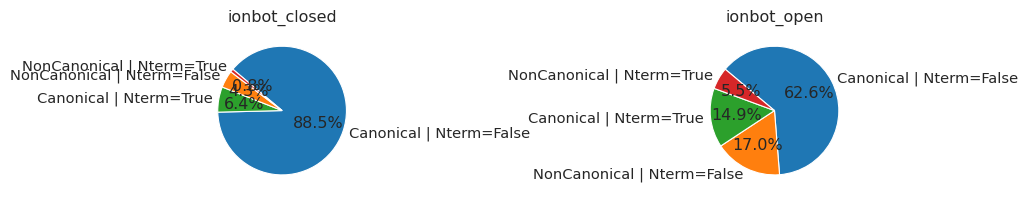

In [173]:
a = data[['pipeline','isCanonical','peptide_nterm']].value_counts().to_frame().reset_index()

# Combine isCanonical + peptide_nterm into one label
a['label'] = a['isCanonical'] + ' | Nterm=' + a['peptide_nterm'].astype(str)

# Get unique pipelines
pipelines = a['pipeline'].unique()

# Consistent colors across pies
unique_labels = a['label'].unique()
colors = plt.cm.tab10(range(len(unique_labels)))  # automatic color cycle
color_map = dict(zip(unique_labels, colors))

# Create side-by-side pie charts
fig, axes = plt.subplots(1, len(pipelines), figsize=(10, 5))

if len(pipelines) == 1:
    axes = [axes]

for ax, pipeline in zip(axes, pipelines):
    subset = a[a['pipeline'] == pipeline]
    ax.pie(
        subset['count'],
        labels=subset['label'],
        autopct='%1.1f%%',
        startangle=140,
        counterclock=False,
        colors=[color_map[l] for l in subset['label']]
    )
    ax.set_title(pipeline)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig(f"{plot_dir}/proteotypic_pep_by_pos_pepcl.svg", format='svg', bbox_inches = 'tight')

In [174]:
from scipy.stats import chisquare

In [175]:
# closed -> open search
# did proportion of N-tem non-canonical peptides changed significantly? ~10%
a.set_index('peptide_nterm').groupby(['pipeline','isCanonical']).apply(lambda x: (x['count']/x['count'].sum())*100)

peptide_nterm                   False      True 
pipeline      isCanonical                       
ionbot_closed Canonical     93.302247   6.697753
              NonCanonical  84.375000  15.625000
ionbot_open   Canonical     80.810093  19.189907
              NonCanonical  75.514874  24.485126

In [176]:
# % into counts - can I do so?
print('Non-canon, open vs closed (expected)',chisquare([75,25], f_exp=[84,16]))
print('Canon, open vs closed (expected)',chisquare([81,19], f_exp=[93,7]))

Non-canon, open vs closed (expected) Power_divergenceResult(statistic=np.float64(6.026785714285714), pvalue=np.float64(0.014090368927114726))
Canon, open vs closed (expected) Power_divergenceResult(statistic=np.float64(22.119815668202765), pvalue=np.float64(2.561519473630783e-06))


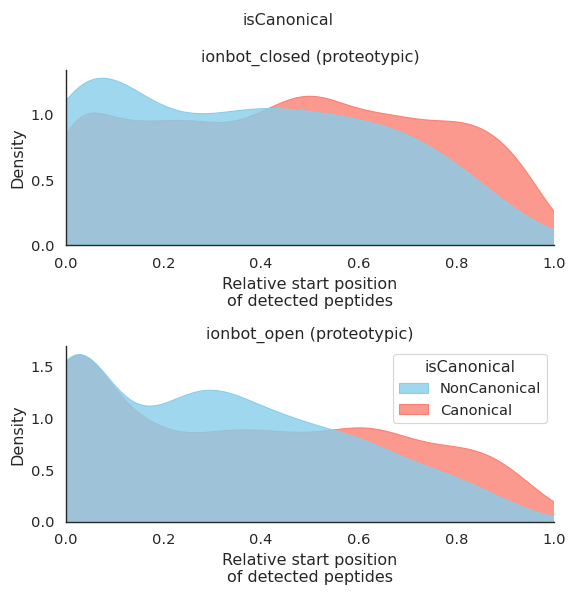

In [178]:
# Define color palette
colors = {"Canonical": "salmon", "NonCanonical": "skyblue"}

# Create subplots — one per pipeline
pipelines = data['pipeline'].unique()
fig, axes = plt.subplots(nrows=len(pipelines), figsize=(6, 3 * len(pipelines)))

# If only one pipeline, axes won’t be an array
if len(pipelines) == 1:
    axes = [axes]

# Loop through pipelines and plot
for i, (ax, pipeline) in enumerate(zip(axes, pipelines)):
    df = data[data['pipeline'] == pipeline]
    sns.kdeplot(
        data=df,
        x='peptide_relative_start',
        hue='isCanonical',
        fill=True,
        palette=colors,
        alpha=0.8,
        hue_order=['NonCanonical', 'Canonical'],
        cut=2,
        ax=ax,
        common_norm=False
    )
    sns.despine()
    ax.set_xlim(0, 1)
    ax.set_xlabel('Relative start position\nof detected peptides')
    ax.set_title(pipeline + ' (proteotypic)')
    if i==0: ax.legend_.remove()  # Remove individual legends

# Add one shared legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=2,
    frameon=False,
    title='isCanonical'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for legend
plt.savefig(f"{plot_dir}/proteotypic_pep_pos_distr.svg", format='svg', bbox_inches = 'tight')


#### Proteotypic theoretical

In [110]:
OPtsv_file="./../oui-discovery-vv-data/raw/ionbot_openprot/human-openprot-2_0-refprots+altprots+isoforms-uniprot2022_06_01.tsv"
OPtsv=pd.read_csv(OPtsv_file,sep="\t",header=None)
OPtsv.columns=["protein accession","protein accession (others)","protein type","protein length (a.a.)",
               "molecular weight (kDa)","isoelectric point","frame","gene symbol","chr","start genomic coordinates",
               "stop genomic coordinates","strand","transcript accession","type","localization","start transcript coordinates",
               "stop transcript coordinates","MS score","TE Translation Event score","Orthology Across 10 Species #:Species Names",
               "Kozak motif","High-efficiency TIS motif"]#,"Domains"]
#Trimm version number from ENS identifier
OPtsv["trx_stab"]=OPtsv["transcript accession"].str[0:15]

/tmp/ipykernel_72322/1345888147.py:2: DtypeWarning:

Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.



In [111]:
#select non-canonical proteins with experimental evidence
op_nc_exper=OPtsv[
    (OPtsv["MS score"] > 0) &
    (
        OPtsv["protein accession"].str.contains("II_") |
        OPtsv["protein accession"].str.contains("IP_")
    )
].drop_duplicates("protein accession")["protein accession"].tolist()

In [112]:
del OPtsv

In [113]:
# digested database with peptide annotation
insituPEP = pd.read_csv("./../../../junk/insitu_peptides.csv")

In [114]:
# take all canonical, non-canonical with expression evedence and only proteotypic peptides
data_theor = insituPEP[((insituPEP.protein_class=="Canon") | (insituPEP.protein.isin(op_nc_exper)))&(insituPEP.isUnique)]

In [115]:
del insituPEP

In [116]:
data_theor.head()

,Unnamed: 0.1,Unnamed: 0,key,peptide,isUnique,protein,peptide_length,peptide_position,protein_class,peptide_class,peptide_start_relative_position,peptide_mass
52,52,52,op|IP_057218|TX=9606,MTCSESAK,True,IP_057218,8,"[(0, 7)]",NonCanon,unique_to_NonCanon,0.000000,NaN
54,54,54,op|IP_057218|TX=9606,SSSSTSLVVWR,True,IP_057218,11,"[(18, 28)]",NonCanon,unique_to_NonCanon,0.545455,NaN
55,55,55,op|IP_057218|TX=9606,MTCSESAKSSPLEAASLK,True,IP_057218,18,"[(0, 17)]",NonCanon,unique_to_NonCanon,0.000000,NaN
56,56,56,op|IP_057218|TX=9606,SSPLEAASLKSSSSTSLVVWR,True,IP_057218,21,"[(8, 28)]",NonCanon,unique_to_NonCanon,0.242424,NaN
57,57,57,op|IP_057218|TX=9606,SSSSTSLVVWRWCCS,True,IP_057218,15,"[(18, 32)]",NonCanon,unique_to_NonCanon,0.545455,NaN


In [ ]:
data_theor.head()

import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette
colors = {"Canon": "salmon", "NonCanon": "skyblue"}

# Create subplots — one per pipeline
pipelines = ['Database']#data['pipeline'].unique()
fig, axes = plt.subplots(nrows=len(pipelines), figsize=(6, 3 * len(pipelines)))

# If only one pipeline, axes won’t be an array
if len(pipelines) == 1:
    axes = [axes]

# Loop through pipelines and plot
for i, (ax, pipeline) in enumerate(zip(axes, pipelines)):
    sns.kdeplot(
        data=data_theor,
        x='peptide_start_relative_position',
        hue='protein_class',
        fill=True,
        palette=colors,
        alpha=0.8,
        hue_order=['NonCanon', 'Canon'],
        cut=2,
        ax=ax,
        common_norm=False
    )
    sns.despine()
    ax.set_xlim(0, 1)
    ax.set_xlabel('Relative start position\nof detected peptides')
    ax.set_title(pipeline + ' (proteotypic)')
    if i==0: ax.legend_.remove()  # Remove individual legends

# Add one shared legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=2,
    frameon=False,
    title='isCanonical'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for legend
plt.savefig(f"{plot_dir}/proteotypic_pep_theor_pos_distr.svg", format='svg', bbox_inches = 'tight')

In [119]:
data_theor['peptide_nterm'] = data_theor['peptide_position'].apply(lambda x: ast.literal_eval(x)[0][0]<3)

In [213]:
data_theor[data_theor['isUnique']].groupby(['protein_class']).apply(lambda x: len(x[x['peptide_nterm']].protein.unique())/len(x.protein.unique()))

protein_class
Canon       0.356280
NonCanon    0.861033
dtype: float64

In [215]:
# relative to each class
data_theor[data_theor['isUnique']].groupby(['protein_class']).apply(lambda x: len(x[x['peptide_nterm']].peptide.unique())/len(x.peptide.unique()))

protein_class
Canon       0.093473
NonCanon    0.181387
dtype: float64

In [222]:
#relative to all peptides
a = len(data_theor[data_theor['isUnique']].peptide.unique())
data_theor[data_theor['isUnique']].groupby(['protein_class']).apply(lambda x: (len(x[x['peptide_nterm']].peptide.unique())/a,len(x[x['peptide_nterm']==False].peptide.unique())/a))

protein_class
Canon       (0.02957310242565935, 0.2868075805488903)
NonCanon    (0.12399988370243557, 0.5596194333230148)
dtype: object

In [120]:
data_theor['pipeline'] = 'database'

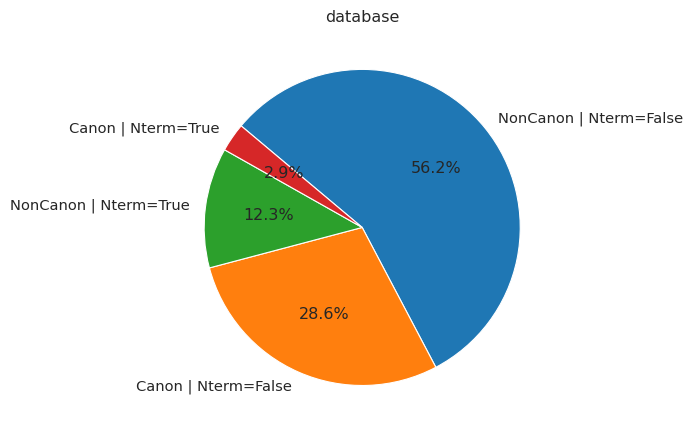

In [121]:
a = data_theor[['pipeline','protein_class','peptide_nterm']].value_counts().to_frame().reset_index()

# Combine isCanonical + peptide_nterm into one label
a['label'] = a['protein_class'] + ' | Nterm=' + a['peptide_nterm'].astype(str)

# Get unique pipelines
pipelines = a['pipeline'].unique()

# Consistent colors across pies
unique_labels = a['label'].unique()
colors = plt.cm.tab10(range(len(unique_labels)))  # automatic color cycle
color_map = dict(zip(unique_labels, colors))

# Create side-by-side pie charts
fig, axes = plt.subplots(1, len(pipelines), figsize=(10, 5))

if len(pipelines) == 1:
    axes = [axes]

for ax, pipeline in zip(axes, pipelines):
    subset = a[a['pipeline'] == pipeline]
    ax.pie(
        subset['count'],
        labels=subset['label'],
        autopct='%1.1f%%',
        startangle=140,
        counterclock=False,
        colors=[color_map[l] for l in subset['label']]
    )
    ax.set_title(pipeline)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig(f"{plot_dir}/proteotypic_pep_by_pos_pepcl_theor.svg", format='svg', bbox_inches = 'tight')

### Residues frequency

In [122]:
from scipy.stats import mannwhitneyu
from statistics import mean, stdev
from math import sqrt
from Download_UnimodDB import *

#### closed vs open search by peptide class

In [128]:
# indicate pipeline
pep_filt_cl['pipeline'] = PIPELINE_CL
pep_filt_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([pep_filt_cl,pep_filt_n])
# select only openprot
data = data[data['search_database']=='openprot']
# drop repeated identifications across samples
data.drop_duplicates(["database_peptide"],inplace=True) #proteins_explode

In [129]:
# aa frequency by peptide
aa_list=list('ACDEFGHIKLMNPQRSTVWY')
for aa in aa_list:
    data[aa]=data['database_peptide'].apply(lambda x: Counter(x)[aa]/len(x))

In [125]:
aa_frq_params = []
for isCanonical, df in data.groupby('isCanonical'):
    for aa in aa_list:
        pipeline_cl = df[df['pipeline'] == PIPELINE_CL][aa].tolist()
        pipeline_n = df[df['pipeline'] == PIPELINE_N][aa].tolist()
        #U1, p = mannwhitneyu(pipeline_cl, pipeline_n, method="exact")
        cohens_d = (np.mean(pipeline_n) - np.mean(pipeline_cl)) / (sqrt((stdev(pipeline_n) ** 2 + stdev(pipeline_cl) ** 2) / 2))
        aa_frq_params += [[isCanonical, aa, cohens_d]]
aa_frq_params = pd.DataFrame(aa_frq_params, columns=['isCanonical', 'aa', 'cohens_d'])

In [126]:
# more than weak
aa_frq_params[abs(aa_frq_params.cohens_d)>0.2]

,isCanonical,aa,cohens_d
1,Canonical,C,0.231012
5,Canonical,G,0.220902
27,NonCanonical,I,-0.235293
28,NonCanonical,K,-0.251584
29,NonCanonical,L,-0.284828
31,NonCanonical,N,0.318087


NameError: name 'stats' is not defined

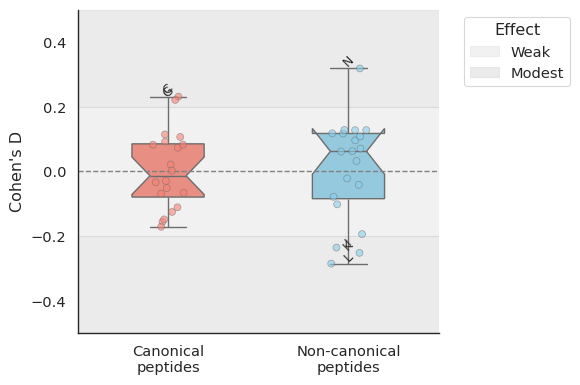

In [127]:
colors = {"Canonical": "salmon", "NonCanonical": "skyblue"}

plt.figure(figsize=(6, 4))

# --- Boxplot (narrower, with fixed order) ---
order = ["Canonical", "NonCanonical"]
ax = sns.boxplot(
    data=aa_frq_params,
    x="isCanonical",
    y="cohens_d",
    hue="isCanonical",
    order=order,
    fliersize=0,
    notch=True,
    width=0.4,
    dodge=False, 
    palette=colors,
)

# --- Add stripplot (aligned exactly with boxplot) ---
sns.stripplot(
    data=aa_frq_params,
    x="isCanonical",
    y="cohens_d",
    hue="isCanonical",
    order=order,
    alpha=0.6,
    jitter=True,
    marker='o',
    linewidth=0.5,
    legend=False,
    dodge=False, 
    ax=ax,
    palette=colors,
)

# --- Label strong effects (aligned with category centers) ---
for i, row in aa_frq_params[abs(aa_frq_params["cohens_d"]) > 0.2].iterrows():
    x_pos = order.index(row["isCanonical"])
    ax.text(
        x_pos,
        row["cohens_d"],
        str(row["aa"]),
        fontsize=9,
        ha='center',
        va='bottom',
        rotation=45
    )

# --- Background shading ---
ax.axhspan(-0.2, 0.2, color='lightgray', alpha=0.3, label="Weak")
ax.axhspan(0.2, 0.5, color='silver', alpha=0.3, label="Modest")
ax.axhspan(-0.5, -0.2, color='silver', alpha=0.3)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)

sns.despine()
plt.ylim(-0.5, 0.5)
plt.ylabel("Cohen's D")
plt.xlim(-0.5,1.5)
plt.xlabel("")
plt.xticks([0,1],['Canonical\npeptides','Non-canonical\npeptides'])
plt.legend(title="Effect", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# --- Statistical test ---
canonical = aa_frq_params.loc[aa_frq_params["isCanonical"] == "Canonical", "cohens_d"]
noncanonical = aa_frq_params.loc[aa_frq_params["isCanonical"] == "NonCanonical", "cohens_d"]

try:
    stat, p = stats.wilcoxon(canonical, noncanonical)
    test_name = "Wilcoxon signed-rank"
except ValueError:
    stat, p = stats.mannwhitneyu(canonical, noncanonical, alternative='two-sided')
    test_name = "Mann–Whitney U"

# --- Annotate significance ---
stars = significance_stars(p)
y_max = max(aa_frq_params['cohens_d']) * 1.3
ax.plot([0, 1], [y_max, y_max], color='dimgray', lw=1.2)
ax.text(0.5, y_max * 1.01, f"{stars}", ha='center', va='bottom', fontsize=11)

plt.savefig(f"{plot_dir}/pep_aafrq_by_pipeline_per_protcl.svg", format='svg', bbox_inches = 'tight')

#### aa with sign diff in frq btw searches ~ top unexpected modifications? -MAKE question more clear. why do you ask it?

In [202]:
def Download_Unimod_Dict_names():
    unimod = Download_UnimodDB()
    condensed_unimod = {}
    for uni_id,df in unimod.groupby("unimod_id").__iter__():
        condensed_unimod[uni_id] = {}
        condensed_unimod[uni_id]['residues'] = "".join([_ for _ in df.residue if '-' not in _])
        condensed_unimod[uni_id]['mono_mass'] = [_ for _ in set(df.mono_mass)][0]
        condensed_unimod[uni_id]['code_name'] = [_ for _ in set(df.code_name)][0]
        condensed_unimod[uni_id]['full_name'] = [_ for _ in set(df.full_name)][0]
        condensed_unimod[uni_id]['classification'] = [_ for _ in set(df.classification)][0]
        
    return condensed_unimod

In [203]:
unimod = Download_Unimod_Dict_names()
unimod_df=pd.DataFrame.from_dict(unimod, orient='index')
unimod_df['residues_explode'] = unimod_df['residues'].apply(list)

In [204]:
top_mod = pd.read_pickle(f'{root}/oui-discovery-vv-data/pickles/ionbot_open_all_pepphorm_mod.pkl')

In [205]:
# skip expected mod (top 3)
top_mod_unimod = unimod_df[unimod_df['mono_mass'].isin(top_mod.index[3:].tolist())].explode('residues_explode')
top_mod_unimod.residues_explode.value_counts()

residues_explode
K    10
S     9
C     8
D     8
T     8
N     8
Q     7
E     7
R     6
H     4
Y     4
A     4
I     3
G     3
P     3
W     3
L     3
V     2
F     2
M     1
U     1
Name: count, dtype: int64

#### canon vs noncanon by search params

In [131]:
aa_frq_pepcl = []
for pipeline, df in data.groupby('pipeline'):
    for aa in aa_list:
        Canon = df[df['isCanonical'] == 'Canonical'][aa].tolist()
        NonCanon = df[df['isCanonical'] == 'NonCanonical'][aa].tolist()
        cohens_d = (np.mean(NonCanon) - np.mean(Canon)) / (sqrt((stdev(NonCanon) ** 2 + stdev(Canon) ** 2) / 2))
        aa_frq_pepcl += [[pipeline, aa, cohens_d]]
aa_frq_pepcl = pd.DataFrame(aa_frq_pepcl, columns=['pipeline', 'aa', 'cohens_d'])

In [142]:
# more than weak
#aa_frq_pepcl[abs(aa_frq_pepcl.cohens_d)>0.2]

In [ ]:
# database

In [133]:
# digested database with peptide annotation
insituPEP = pd.read_csv("./../../../junk/insitu_peptides.csv")

In [134]:
# take all canonical, non-canonical with expression evedence and only proteotypic peptides
data_db = insituPEP[((insituPEP.protein_class=="Canon") | (insituPEP.protein.isin(op_nc_exper)))]

In [135]:
del insituPEP

In [136]:
# aa frequency by peptide
aa_list=list('ACDEFGHIKLMNPQRSTVWY')
for aa in aa_list:
    data_db[aa]=data_db['peptide'].apply(lambda x: Counter(x)[aa]/len(x))

In [139]:
aa_frq_pepcl_db = []
for pipeline in ['database']:
    for aa in aa_list:
        Canon = data_db[data_db['protein_class'] == 'Canon'][aa].tolist()
        NonCanon = data_db[data_db['protein_class'] == 'NonCanon'][aa].tolist()
        cohens_d = (np.mean(NonCanon) - np.mean(Canon)) / (sqrt((stdev(NonCanon) ** 2 + stdev(Canon) ** 2) / 2))
        aa_frq_pepcl_db += [[pipeline, aa, cohens_d]]
aa_frq_pepcl_db = pd.DataFrame(aa_frq_pepcl_db, columns=['pipeline', 'aa', 'cohens_d'])

In [143]:
del data_db

In [141]:
# more than weak
#aa_frq_pepcl_db[abs(aa_frq_pepcl_db.cohens_d)>0.2]

In [ ]:
# merge searches and database

In [144]:
aa_frq_pepcl = pd.concat([aa_frq_pepcl,aa_frq_pepcl_db])

In [145]:
# more than weak
aa_frq_pepcl[abs(aa_frq_pepcl.cohens_d)>0.2]

,pipeline,aa,cohens_d
7,ionbot_closed,I,0.300852
10,ionbot_closed,M,0.315082
14,ionbot_closed,R,-0.236782
27,ionbot_open,I,0.249784
30,ionbot_open,M,0.368496
31,ionbot_open,N,0.312610
32,ionbot_open,P,-0.301372
34,ionbot_open,R,-0.477070
1,database,C,0.256827
2,database,D,-0.392741


In [206]:
aa_frq_pepcl[(aa_frq_pepcl.pipeline!='database')&(abs(aa_frq_pepcl.cohens_d)<=0.2)].groupby('pipeline').apply(len)/20

pipeline
ionbot_closed    0.85
ionbot_open      0.75
dtype: float64

In [ ]:
# plot

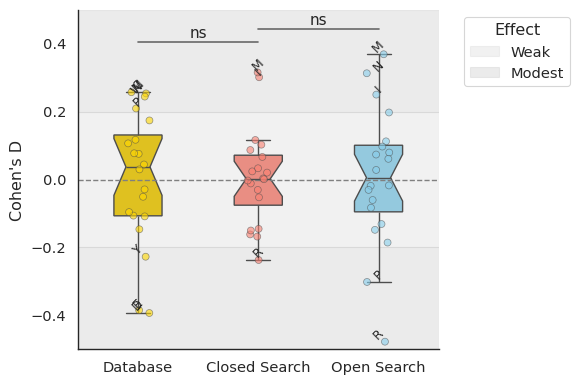

In [166]:
colors = {"database":"gold","ionbot_closed": "salmon", "ionbot_open": "skyblue"}

plt.figure(figsize=(6, 4))

# --- Boxplot (narrower, with fixed order) ---
order = ["database", "ionbot_closed","ionbot_open"]
ax = sns.boxplot(
    data=aa_frq_pepcl,
    x="pipeline",
    y="cohens_d",
    hue="pipeline",
    order=order,
    fliersize=0,
    notch=True,
    width=0.4,
    dodge=False, 
    palette=colors,
)

# --- Add stripplot (aligned exactly with boxplot) ---
sns.stripplot(
    data=aa_frq_pepcl,
    x="pipeline",
    y="cohens_d",
    hue="pipeline",
    order=order,
    alpha=0.6,
    jitter=True,
    marker='o',
    linewidth=0.5,
    legend=False,
    dodge=False, 
    ax=ax,
    palette=colors,
)

# --- Label strong effects (aligned with category centers) ---
for i, row in aa_frq_pepcl[abs(aa_frq_pepcl["cohens_d"]) > 0.2].iterrows():
    x_pos = order.index(row["pipeline"])
    ax.text(
        x_pos,
        row["cohens_d"],
        str(row["aa"]),
        fontsize=9,
        ha='center',
        va='bottom',
        rotation=45
    )

# --- Background shading ---
ax.axhspan(-0.2, 0.2, color='lightgray', alpha=0.3, label="Weak")
ax.axhspan(0.2, 0.5, color='silver', alpha=0.3, label="Modest")
ax.axhspan(-0.5, -0.2, color='silver', alpha=0.3)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)

sns.despine()
plt.ylim(-0.5, 0.5)
plt.ylabel("Cohen's D")
plt.xlim(-0.5,2.5)
plt.xlabel("")
plt.xticks([0,1,2],['Database','Closed Search','Open Search'])
plt.legend(title="Effect", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# --- Statistical test ---
ionbot_closed = aa_frq_pepcl.loc[aa_frq_pepcl["pipeline"] == "ionbot_closed", "cohens_d"]
ionbot_open = aa_frq_pepcl.loc[aa_frq_pepcl["pipeline"] == "ionbot_open", "cohens_d"]

try:
    stat, p = stats.wilcoxon(ionbot_closed, ionbot_open)
    test_name = "Wilcoxon signed-rank"
except ValueError:
    stat, p = stats.mannwhitneyu(ionbot_closed, ionbot_open, alternative='two-sided')
    test_name = "Mann–Whitney U"

# --- Annotate significance ---
stars = significance_stars(p)
y_max = max(aa_frq_pepcl['cohens_d']) * 1.2
ax.plot([1, 2], [y_max, y_max], color='dimgray', lw=1.2)
ax.text(1.5, y_max * 1.01, f"{stars}", ha='center', va='bottom', fontsize=11)

# --- Statistical test ---
database = aa_frq_pepcl.loc[aa_frq_pepcl["pipeline"] == "database", "cohens_d"]
ionbot_closed = aa_frq_pepcl.loc[aa_frq_pepcl["pipeline"] == "ionbot_closed", "cohens_d"]

try:
    stat, p = stats.wilcoxon(database, ionbot_closed)
    test_name = "Wilcoxon signed-rank"
except ValueError:
    stat, p = stats.mannwhitneyu(database, ionbot_closed, alternative='two-sided')
    test_name = "Mann–Whitney U"

# --- Annotate significance ---
stars = significance_stars(p)
y_max = max(aa_frq_pepcl['cohens_d']) * 1.1
ax.plot([0, 1], [y_max, y_max], color='dimgray', lw=1.2)
ax.text(0.5, y_max * 1.01, f"{stars}", ha='center', va='bottom', fontsize=11)

plt.savefig(f"{plot_dir}/pep_aafrq_by_protcl_per_source.svg", format='svg', bbox_inches = 'tight')

### closed vs open peptide length by peptide class

In [185]:
# indicate pipeline
pep_filt_cl['pipeline'] = PIPELINE_CL
pep_filt_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([pep_filt_cl,pep_filt_n])
# select only openprot
data = data[data['search_database']=='openprot']
# drop repeated identifications across samples
data.drop_duplicates(["database_peptide"],inplace=True) #proteins_explode

In [186]:
protein_class_order=['Canonical','NonCanonical']

/tmp/ipykernel_72322/1652276575.py:63: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



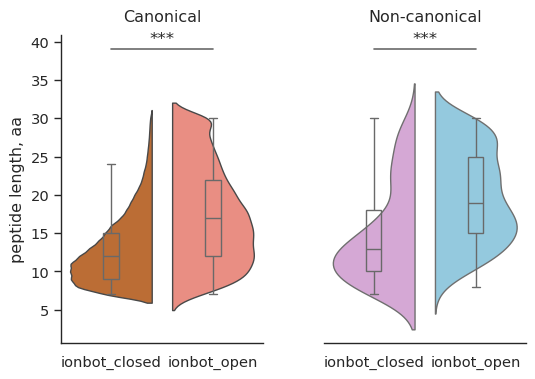

In [187]:
data['pep_len'] = data['database_peptide'].apply(len)

# carefull common peptides included!

color_map = {
    PIPELINE_CL:{
        "Canonical": project_palette2[f"{PIPELINE_CL}_canon_unique"],
        "NonCanonical": project_palette2[f"{PIPELINE_CL}_noncanon_unique"],
        },
    PIPELINE_N:{
        "Canonical": project_palette2[f"{PIPELINE_N_NAME}_canon_unique"],
        "NonCanonical": project_palette2[f"{PIPELINE_N_NAME}_noncanon_unique"],
        }
}

# plot
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)

for i, protein_class in enumerate(protein_class_order):
    subset = data[data['isCanonical'] == protein_class]
    # violin
    sns.violinplot(data=subset, 
                   x='pipeline', y='pep_len', 
                   split=True, hue='pipeline', ax=axes[i],
                   inner=None, dodge=False,
                   palette={PIPELINE_CL: color_map[PIPELINE_CL][protein_class], 
                            PIPELINE_N: color_map[PIPELINE_N][protein_class]},
                   linewidth=1)

    # box overlay
    sns.boxplot(data=subset,
                x='pipeline', y='pep_len',
                width=0.15, dodge=False,
                boxprops={"facecolor": "none", "edgecolor": "dimgrey", "linewidth": 1},
                whiskerprops={"color": "dimgrey", "linewidth": 1},
                capprops={"color": "dimgrey", "linewidth": 1},
                medianprops={"color": "dimgrey", "linewidth": 1},
                showfliers=False, ax=axes[i], zorder=50)

    # --- MannWhitney test between pipelines ---
    vals_cl = subset[subset['pipeline'] == PIPELINE_CL]['pep_len']
    vals_n = subset[subset['pipeline'] == PIPELINE_N]['pep_len']

    U1, p = mannwhitneyu(vals_cl, vals_n)
    stars = significance_stars(p)

    # Add annotation
    y_max = max(subset['pep_len']) * 1.3
    axes[i].plot([0, 1], [y_max, y_max], color='dimgray', lw=1.2)
    axes[i].text(0.5, y_max * 1.01, stars, ha='center', va='bottom', fontsize=12)


    axes[i].set_title(protein_class if protein_class=='Canonical' else 'Non-canonical', pad=10)

# aesthetics
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    ax.spines['left'].set_visible(False)
    ax.set_ylabel('') 
    ax.set_xlabel('')
    ax.tick_params(left=False) 
    l = ax.legend().get_frame()
    l.set_edgecolor("white")

# Keep only y-axis on first plot
axes[0].spines['left'].set_visible(True)
axes[0].set_ylabel("peptide length, aa") 
axes[0].tick_params(left=True)

fig.subplots_adjust(wspace=.3)
plt.savefig(f"{plot_dir}/pep_len_by_protcl.svg", format='svg', bbox_inches = 'tight')

In [ ]:
# longer peptides are more likely to be unique

In [196]:
data['isShort']=data['pep_len']<=15
df = data[['pipeline','isCanonical','isShort']].value_counts().reset_index()
# Step 1: calculate total counts per group
total_counts = df.groupby(['pipeline', 'isCanonical'])['count'].transform('sum')
# Step 2: calculate percentage
df['percent'] = df['count'] / total_counts * 100
df

,pipeline,isCanonical,isShort,count,percent
0,ionbot_closed,Canonical,True,31788,75.984224
1,ionbot_closed,Canonical,False,10047,24.015776
2,ionbot_open,Canonical,False,5440,56.484270
3,ionbot_open,Canonical,True,4191,43.515730
4,ionbot_open,NonCanonical,False,335,70.824524
5,ionbot_open,NonCanonical,True,138,29.175476
6,ionbot_closed,NonCanonical,True,100,67.114094
7,ionbot_closed,NonCanonical,False,49,32.885906


In [201]:
a = df[(df['pipeline']=='ionbot_closed')&(df['isCanonical']=='Canonical')&(df['isShort']==False)]['percent'].iloc[0]
b = df[(df['pipeline']=='ionbot_open')&(df['isCanonical']=='Canonical')&(df['isShort']==False)]['percent'].iloc[0]
print('>15 aa open-closed', b-a)
a = df[(df['pipeline']=='ionbot_closed')&(df['isCanonical']=='NonCanonical')&(df['isShort']==False)]['percent'].iloc[0]
b = df[(df['pipeline']=='ionbot_open')&(df['isCanonical']=='NonCanonical')&(df['isShort']==False)]['percent'].iloc[0]
print('>15 aa open-closed', b-a)

>15 aa open-closed 32.46849328236301
>15 aa open-closed 37.938618272627956


### Unfiltered score distribution by peptide class

In [ ]:
#load peptides

processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# classical
# get processed files
processed_paths_cl=dt.list_files(processed_dir)
# leave only non-entrapment and closed search, only search files
tmp = processed_paths_cl.copy()
for parent, files in processed_paths_cl.items():
    if '.v0.11.4' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths_cl = tmp
pep_cl = []
for parent, files in processed_paths_cl.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output-peptide-vv.csv' :
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-2])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            pep_cl += [data]
pep_cl = pd.concat(pep_cl)
pep_cl = pep_cl[(pep_cl['isCanonical'] != 'Contam')]
pep_cl['proteins'] = pep_cl['proteins'].apply(lambda x: x.split(';'))
pep_cl['isProteotypic'] = pep_cl['proteins'].apply(lambda x: len(x)==1)
pep_cl["peptide_class"]=pep_cl["proteins"].apply(tpp.classify_peptide_tpp)

# new
# get processed files
processed_paths_n=dt.list_files(processed_dir)
# leave only non-entrapment and open search, only search files
tmp = processed_paths_n.copy()
for parent, files in processed_paths_n.items():
    if '-closed' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths_n = tmp
pep_n = []
for parent, files in processed_paths_n.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output-peptide-vv.csv' :
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            pep_n += [data]
pep_n = pd.concat(pep_n)
pep_n = pep_n[(pep_n['isCanonical'] != 'Contam')]
pep_n['proteins'] = pep_n['proteins'].apply(lambda x: x.split(';'))
pep_n['isProteotypic'] = pep_n['proteins'].apply(lambda x: len(x)==1)
pep_n["peptide_class"]=pep_n["proteins"].apply(tpp.classify_peptide_tpp)

In [ ]:
# indicate pipeline
pep_cl['pipeline'] = PIPELINE_CL
pep_n['pipeline'] = PIPELINE_N
#merge
data = pd.concat([pep_cl,pep_n])
# select only openprot
data = data[data['search_database']=='openprot']
# drop repeated identifications across samples
data.drop_duplicates(["database_peptide"],inplace=True) #proteins_explode
# categories
data['isCanonical_database'] = data['isCanonical'] +'_'+ data['database']

In [ ]:
color_map = {
        "Canonical": project_palette2[f"{PIPELINE_N_NAME}_canon_unique"],
        "NonCanonical": project_palette2[f"{PIPELINE_N_NAME}_noncanon_unique"],
}

In [ ]:
# Get all unique pipelines
pipelines = data['pipeline'].unique()

# Create subplots
fig, axes = plt.subplots(len(pipelines), 1, figsize=(8, 4 * len(pipelines)), sharex=True)

if len(pipelines) == 1:
    axes = [axes]  # make iterable if only one pipeline

# Iterate over pipelines
for ax, pipeline in zip(axes, pipelines):
    df_p = data[data['pipeline'] == pipeline]

    # KDE plot per pipeline
    sns.kdeplot(
        data=df_p,
        x='psm_score',
        hue='isCanonical_database',
        fill=True,
        cut=0,
        alpha=0.6,
        ax=ax
    )
    sns.despine()

    # Global threshold line
    global_score = df_p[df_p['q.value'] < 0.01]['psm_score'].min()
    if pd.notna(global_score):
        ax.axvline(x=global_score, color='black', linestyle='-', label='Global FDR<1%')

    # Group-specific threshold lines
    for isCanonical, df2 in df_p.groupby('isCanonical'):
        group_score = df2[df2['group_qval'] < 0.01]['psm_score'].min()
        if pd.notna(group_score):
            ax.axvline(
                x=group_score,
                linestyle='--',
                color=color_map[isCanonical],
                label=f'{isCanonical} Group-Walk FDR<1%'
            )

    ax.set_title(pipeline)
    ax.set_xlim(df_p['psm_score'].min(), df_p['psm_score'].max())
    #ax.set_xlim(-0.5, 2)

# --- Shared legend (one for all subplots) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, title='Max psm_score')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{plot_dir}/unfilt_pep_score_distr.svg", format='svg', bbox_inches = 'tight')

In [ ]:
# Get all unique pipelines
pipelines = data['pipeline'].unique()

# Create subplots
fig, axes = plt.subplots(len(pipelines), 1, figsize=(8, 4 * len(pipelines)), sharex=True)

if len(pipelines) == 1:
    axes = [axes]  # make iterable if only one pipeline

# Iterate over pipelines
for ax, pipeline in zip(axes, pipelines):
    df_p = data[data['pipeline'] == pipeline]

    # Histogram (replace KDE)
    sns.histplot(
        data=df_p,
        x='psm_score',
        hue='isCanonical_database',
        multiple='stack',
        stat='count',  # absolute counts
        binwidth=0.05, # adjust as needed
        #palette=color_map,
        ax=ax,
        alpha=0.7
    )
    
    # Global threshold line
    global_score = df_p[df_p['q.value'] < 0.01]['psm_score'].min()
    if pd.notna(global_score):
        ax.axvline(x=global_score, color='black', linestyle='-', label='Global FDR<1%')

    # Group-specific threshold lines
    for isCanonical, df2 in df_p.groupby('isCanonical'):
        group_score = df2[df2['group_qval'] < 0.01]['psm_score'].min()
        if pd.notna(group_score):
            ax.axvline(
                x=group_score,
                linestyle='--',
                color=color_map[isCanonical],
                label=f'{isCanonical} Group-Walk FDR<1%'
            )

    ax.set_title(pipeline)
    sns.despine(ax=ax)

    zoom = True
    if zoom: ax.set_xlim(-0.5,2)

# --- Shared legend (one for all subplots) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, title='PSM score')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{plot_dir}/unfilt_pep_score_hist{ '_zoom' if zoom else '' }.svg", format='svg', bbox_inches='tight')
